<a href="https://colab.research.google.com/github/PachecoRo/Prueba/blob/main/Parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAICES

Raíces de f1(x) = x^3-2*x-5:
: [-1.04727574077116 - 1.13593988908893*I, -1.04727574077116 + 1.13593988908893*I, 2.09455148154233]

Raíces de f2(x) = x^3-x-2:
: [-0.760689853402284 - 0.857873626595179*I, -0.760689853402284 + 0.857873626595179*I, 1.52137970680457]

Raíces de f3(x) = x^4-5*x^2:
: [0, -2.23606797749979, 2.23606797749979]

Raíces de f4(x) = x^5-x-1:
: [1.16730397826142, -0.764884433600585 - 0.352471546031726*I, -0.764884433600585 + 0.352471546031726*I, 0.181232444469875 - 1.08395410131771*I, 0.181232444469875 + 1.08395410131771*I]

Raíces de f5(x) = e^x-4*x:
: [0.357402956181389]



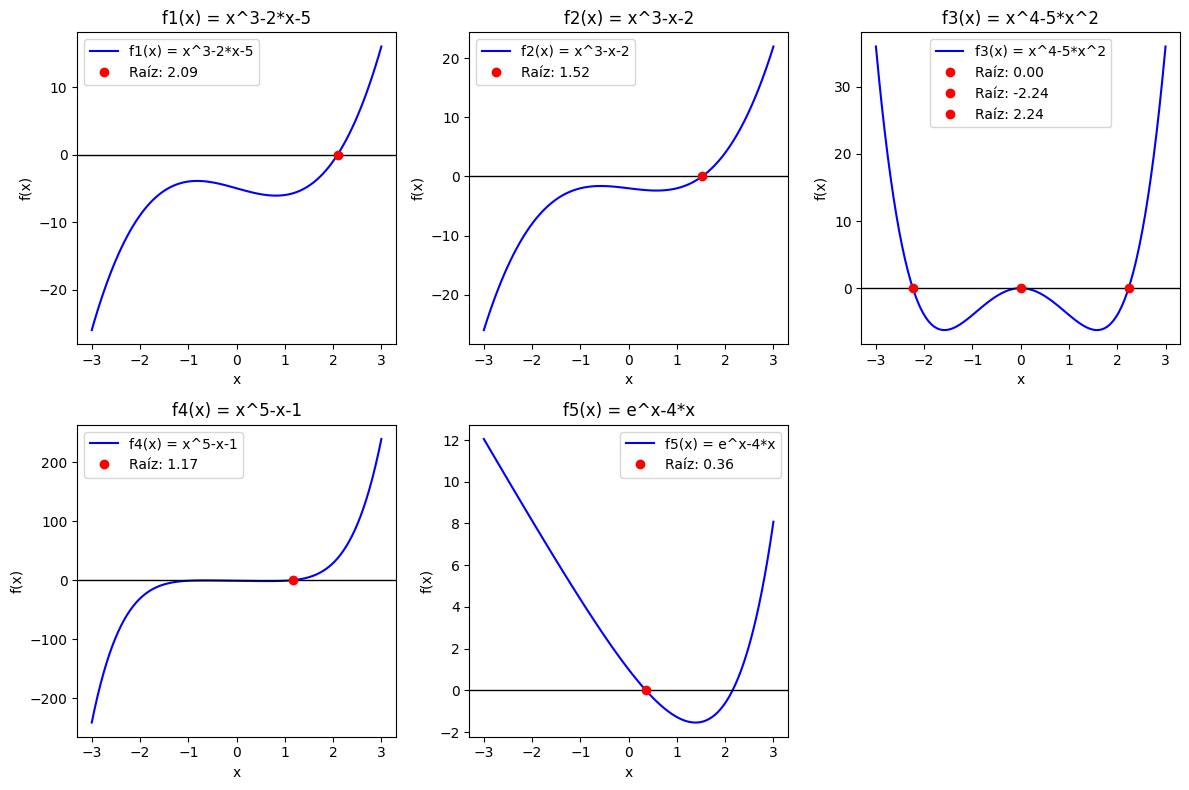

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import pandas as pd

x = sp.symbols('x')

#Defino mis funciones
Funciones = {
    "f1(x) = x^3-2*x-5": x**3-2*x-5,
    "f2(x) = x^3-x-2": x**3-x-2,
    "f3(x) = x^4-5*x^2": x**4-5*x**2,
    "f4(x) = x^5-x-1": x**5-x-1,
    "f5(x) = e^x-4*x": sp.exp(x)-4*x
}

#Resuelvo las raices
for nombre, funcion in Funciones.items(): #Uso esto pq hice el diccionario arriba para no tener que escribir una por unna la funcion y sus raices,
#con esto se supone que mme lo va a hacer todo junto.
  raices = sp.solve(funcion, x)
  raices_aprox = [r.evalf() for r in raices]
  print(f"Raíces de {nombre}:")
  print(f": {raices_aprox}\n")

plt.figure(figsize=(12, 8))  # Tamaño del gráfico, esto seria si no entiendo mal, uno grrande para tener varios ploteos

for i, (nombre, funcion) in enumerate(Funciones.items()):
    raices_aprox = sp.solve(funcion, x)  # Obtengo llas raíces exactas
    raices_aprox = [r.evalf() for r in raices_aprox]  # La convierto a aprox decimales

    # Creo una función numérica a partir de la simbólica para poder graficar
    f_num = sp.lambdify(x, funcion, 'numpy')

    #rango de valores para el gráfico
    X = np.linspace(3, -3, 100)
    Y = f_num(X)

    plt.subplot(2, 3, i + 1)
    plt.plot(X, Y, label=nombre, color='blue')  #grafico las funciones
    plt.axhline(0, color='black', lw=1)  #hago una linea negrita en el 0 asi puedo ver mas facil donde la funcion cruza esta linea

    #AHora lo que quiero hacer es que en los graficos se me marque con un pto rojo donde estan las raices
    for raiz in raices_aprox:
      if raiz.is_real:
        plt.plot(float(raiz), 0, 'ro', label=f'Raíz: {raiz:.2f}')

    plt.title(nombre)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()

plt.tight_layout()
plt.show()


# BISECCION

In [116]:
#Defino mi intervalo inicial
iterations = 100
tolerancia = 1e-4

#ahora realizo el metodo de biseccion para las funnciones, con las iteraciones que puse
for nombre, funcion in Funciones.items():
  a, b = 3, -3
  print(f"Intervalo inicial: [{a}, {b}]")

  if sp.N(funcion.subs(x, a)) * sp.N(funcion.subs(x, b)) >= 0:
        print(f"No se puede aplicar el método de bisección a {nombre} en el intervalo [{a}, {b}]")
        continue

  print(f"\nAnalizando {nombre} en el intervalo inicial: [{a}, {b}]")

  # aplico el método de bisección
  for i in range(iterations):
      c = (a + b) / 2  #punto medio
      fc = funcion.subs(x, c)

      print(f"Iteración {i + 1}:")
      print(f" - Punto medio c = {c:.4f}")
      print(f" - f(c) = {fc:.4f}")

      #tolerancia
      # verifico si la tolerancia se alcanza
      if abs(fc) < 1e-4:
          print(f"Se encontró una raíz aproximada: {c:.4f} en la iteración {i + 1}")
          break

      # actualizo el intervalo
      if funcion.subs(x, a) * fc < 0:  # si hay signos opuestos entonces hay una raiz entre a y c
          b = c
      else:  # hay raíz entre c y b
          a = c

      print(f"Nuevo intervalo: [{a:.4f}, {b:.4f}]")

  print(f"Después de {iterations} iteraciones, la raíz aproximada es: {c:.4f}\n")


Intervalo inicial: [3, -3]

Analizando f1(x) = x^3-2*x-5 en el intervalo inicial: [3, -3]
Iteración 1:
 - Punto medio c = 0.0000
 - f(c) = -5.0000
Nuevo intervalo: [3.0000, 0.0000]
Iteración 2:
 - Punto medio c = 1.5000
 - f(c) = -4.6250
Nuevo intervalo: [3.0000, 1.5000]
Iteración 3:
 - Punto medio c = 2.2500
 - f(c) = 1.8906
Nuevo intervalo: [2.2500, 1.5000]
Iteración 4:
 - Punto medio c = 1.8750
 - f(c) = -2.1582
Nuevo intervalo: [2.2500, 1.8750]
Iteración 5:
 - Punto medio c = 2.0625
 - f(c) = -0.3513
Nuevo intervalo: [2.2500, 2.0625]
Iteración 6:
 - Punto medio c = 2.1562
 - f(c) = 0.7128
Nuevo intervalo: [2.1562, 2.0625]
Iteración 7:
 - Punto medio c = 2.1094
 - f(c) = 0.1668
Nuevo intervalo: [2.1094, 2.0625]
Iteración 8:
 - Punto medio c = 2.0859
 - f(c) = -0.0957
Nuevo intervalo: [2.1094, 2.0859]
Iteración 9:
 - Punto medio c = 2.0977
 - f(c) = 0.0347
Nuevo intervalo: [2.0977, 2.0859]
Iteración 10:
 - Punto medio c = 2.0918
 - f(c) = -0.0307
Nuevo intervalo: [2.0977, 2.0918]
Ite

# Punto fijo

In [115]:
for nombre, g in Funciones_g.items():
  Funciones_g = {
    "f1(x)": (2*x + 5)**(1/3),
    "f2(x)": (x + 2)**(1/3),
    "f3(x)": (5*x**2)**(1/4), #ya
    "f4(x)": (x + 1)**(1/5),
    "f5(x)": sp.exp(x) / 4  # ya solucione ya, lo que pasaba es que con otra forma que yo habia sacado la g(x) no me daban las raices, ahora que transforme de otra fomra, si me da
  }

maximas_iteraciones = 100
toleration = 1e-4

def punto_fijo(g, x0):
    iteraciones = []
    for i in range(maximas_iteraciones):
        x1 = g.evalf(subs={x: x0})
        iteraciones.append((i + 1, x0, x1))

        if abs(x1 - x0) < toleration:
            return x1, iteraciones  #que me devuelva la raiz arpox y las iteraciones
        x0 = x1  # actualizo el valor de x

    return None, iteraciones #si no se encuentra la raiz en el nro max de iteraciones

#entonces ahora lo que voy a hacer es que voy a hacer este metodo pero para todas mis funciones dentro d mi dicccionario
for nombre, g in Funciones_g.items():
    print(f"Procesando {nombre} con g(x) = {g}")

    X0 = 0.5
    raiz, iteraciones = punto_fijo(g, X0)

    if raiz is not None:
      print(f"-Raíz aprox: {raiz}")
    else:
      print(f"-No se encontro una raíz en el número máximo de iteraciones")


    print(f"Se encontraron {len(iteraciones)} iteraciones para {nombre}.")


Procesando f1(x) con g(x) = (2*x + 5)**0.333333333333333
-Raíz aprox: 2.09454798149912
Se encontraron 7 iteraciones para f1(x).
Procesando f2(x) con g(x) = (x + 2)**0.333333333333333
-Raíz aprox: 1.52136934716296
Se encontraron 6 iteraciones para f2(x).
Procesando f3(x) con g(x) = 1.49534878122122*(x**2)**0.25
-Raíz aprox: 2.23601687135618
Se encontraron 16 iteraciones para f3(x).
Procesando f4(x) con g(x) = (x + 1)**0.2
-Raíz aprox: 1.16729262989532
Se encontraron 5 iteraciones para f4(x).
Procesando f5(x) con g(x) = exp(x)/4
-Raíz aprox: 0.357445563056810
Se encontraron 8 iteraciones para f5(x).


# Newton

In [117]:
max_iter = 100
tol = 1e-4
for nombre, f in Funciones.items():
  #Ahora defino el metodo de newton
  def newton(f, x0):
    f_derivada = sp.diff(f, x)
    iteraciones = []

    for i in range(max_iter):
        f_x0 = f.evalf(subs={x: x0})
        f_prime_x0 = f_derivada.evalf(subs={x: x0})

        if f_prime_x0 == 0:
            print(f" - Derivada cero en la iteración {i + 1}. No se puede continuar.")
            return None, iteraciones

        # calculo la nueva aprox
        x1 = x0 - f_x0 / f_prime_x0
        iteraciones.append((i + 1, x0, x1))

        if abs(x1 - x0) < tol:
            return x1, iteraciones

        x0 = x1

    return None, iteraciones

#Ahora aplico el metodo de newton para todas las funciones de mi lista
for nombre, f in Funciones.items():
    print(f"Procesando {nombre}")

    x0 = 1
    raiz, iteraciones = newton(f, x0)

    if raiz is not None:
        print(f"- Raíz aprox: {raiz}")
    else:
        print("- No se encontró una raíz en el número máximo de iteraciones")

    print(f"Se encontraron {len(iteraciones)} iteraciones para {nombre}.")





Procesando f1(x) = x^3-2*x-5
- Raíz aprox: 2.09455148156421
Se encontraron 8 iteraciones para f1(x) = x^3-2*x-5.
Procesando f2(x) = x^3-x-2
- Raíz aprox: 1.52137970973315
Se encontraron 5 iteraciones para f2(x) = x^3-x-2.
Procesando f3(x) = x^4-5*x^2
- Raíz aprox: 0.0000789235012513717
Se encontraron 13 iteraciones para f3(x) = x^4-5*x^2.
Procesando f4(x) = x^5-x-1
- Raíz aprox: 1.16730397826144
Se encontraron 5 iteraciones para f4(x) = x^5-x-1.
Procesando f5(x) = e^x-4*x
- Raíz aprox: 0.357402956181389
Se encontraron 5 iteraciones para f5(x) = e^x-4*x.


# Punto de las tolerancias

##Punto b

###Tolerancia 1e-2

In [41]:
#Defino mi intervalo inicial
iterations = 15
tolerancia = 1e-2

#ahora realizo el metodo de biseccion para las funnciones, con las iteraciones que puse
for nombre, funcion in Funciones.items():
  a, b = 3, -3
  print(f"Intervalo inicial: [{a}, {b}]")

  if sp.N(funcion.subs(x, a)) * sp.N(funcion.subs(x, b)) >= 0:
        print(f"No se puede aplicar el método de bisección a {nombre} en el intervalo [{a}, {b}]")
        continue

  print(f"\nAnalizando {nombre} en el intervalo inicial: [{a}, {b}]")

  # aplico el método de bisección
  for i in range(iterations):
      c = (a + b) / 2  #punto medio
      fc = funcion.subs(x, c)

      print(f"Iteración {i + 1}:")
      print(f" - Punto medio c = {c:.4f}")
      print(f" - f(c) = {fc:.4f}")

      #tolerancia
      # verifico si la tolerancia se alcanza
      if abs(fc) < 1e-4:
          print(f"Se encontró una raíz aproximada: {c:.4f} en la iteración {i + 1}")
          break

      # actualizo el intervalo
      if funcion.subs(x, a) * fc < 0:  # si hay signos opuestos entonces hay una raiz entre a y c
          b = c
      else:  # hay raíz entre c y b
          a = c

      print(f"Nuevo intervalo: [{a:.4f}, {b:.4f}]")

  print(f"Después de {iterations} iteraciones, la raíz aproximada es: {c:.4f}\n")

Intervalo inicial: [3, -3]

Analizando f1(x) = x^3-2*x-5 en el intervalo inicial: [3, -3]
Iteración 1:
 - Punto medio c = 0.0000
 - f(c) = -5.0000
Nuevo intervalo: [3.0000, 0.0000]
Iteración 2:
 - Punto medio c = 1.5000
 - f(c) = -4.6250
Nuevo intervalo: [3.0000, 1.5000]
Iteración 3:
 - Punto medio c = 2.2500
 - f(c) = 1.8906
Nuevo intervalo: [2.2500, 1.5000]
Iteración 4:
 - Punto medio c = 1.8750
 - f(c) = -2.1582
Nuevo intervalo: [2.2500, 1.8750]
Iteración 5:
 - Punto medio c = 2.0625
 - f(c) = -0.3513
Nuevo intervalo: [2.2500, 2.0625]
Iteración 6:
 - Punto medio c = 2.1562
 - f(c) = 0.7128
Nuevo intervalo: [2.1562, 2.0625]
Iteración 7:
 - Punto medio c = 2.1094
 - f(c) = 0.1668
Nuevo intervalo: [2.1094, 2.0625]
Iteración 8:
 - Punto medio c = 2.0859
 - f(c) = -0.0957
Nuevo intervalo: [2.1094, 2.0859]
Iteración 9:
 - Punto medio c = 2.0977
 - f(c) = 0.0347
Nuevo intervalo: [2.0977, 2.0859]
Iteración 10:
 - Punto medio c = 2.0918
 - f(c) = -0.0307
Nuevo intervalo: [2.0977, 2.0918]
Ite

###Tolerancia 1e-5

In [42]:
#Defino mi intervalo inicial
iterations = 15
tolerancia = 1e-5

#ahora realizo el metodo de biseccion para las funnciones, con las iteraciones que puse
for nombre, funcion in Funciones.items():
  a, b = 3, -3
  print(f"Intervalo inicial: [{a}, {b}]")

  if sp.N(funcion.subs(x, a)) * sp.N(funcion.subs(x, b)) >= 0:
        print(f"No se puede aplicar el método de bisección a {nombre} en el intervalo [{a}, {b}]")
        continue

  print(f"\nAnalizando {nombre} en el intervalo inicial: [{a}, {b}]")

  # aplico el método de bisección
  for i in range(iterations):
      c = (a + b) / 2  #punto medio
      fc = funcion.subs(x, c)

      print(f"Iteración {i + 1}:")
      print(f" - Punto medio c = {c:.4f}")
      print(f" - f(c) = {fc:.4f}")

      #tolerancia
      # verifico si la tolerancia se alcanza
      if abs(fc) < 1e-4:
          print(f"Se encontró una raíz aproximada: {c:.4f} en la iteración {i + 1}")
          break

      # actualizo el intervalo
      if funcion.subs(x, a) * fc < 0:  # si hay signos opuestos entonces hay una raiz entre a y c
          b = c
      else:  # hay raíz entre c y b
          a = c

      print(f"Nuevo intervalo: [{a:.4f}, {b:.4f}]")

  print(f"Después de {iterations} iteraciones, la raíz aproximada es: {c:.4f}\n")

Intervalo inicial: [3, -3]

Analizando f1(x) = x^3-2*x-5 en el intervalo inicial: [3, -3]
Iteración 1:
 - Punto medio c = 0.0000
 - f(c) = -5.0000
Nuevo intervalo: [3.0000, 0.0000]
Iteración 2:
 - Punto medio c = 1.5000
 - f(c) = -4.6250
Nuevo intervalo: [3.0000, 1.5000]
Iteración 3:
 - Punto medio c = 2.2500
 - f(c) = 1.8906
Nuevo intervalo: [2.2500, 1.5000]
Iteración 4:
 - Punto medio c = 1.8750
 - f(c) = -2.1582
Nuevo intervalo: [2.2500, 1.8750]
Iteración 5:
 - Punto medio c = 2.0625
 - f(c) = -0.3513
Nuevo intervalo: [2.2500, 2.0625]
Iteración 6:
 - Punto medio c = 2.1562
 - f(c) = 0.7128
Nuevo intervalo: [2.1562, 2.0625]
Iteración 7:
 - Punto medio c = 2.1094
 - f(c) = 0.1668
Nuevo intervalo: [2.1094, 2.0625]
Iteración 8:
 - Punto medio c = 2.0859
 - f(c) = -0.0957
Nuevo intervalo: [2.1094, 2.0859]
Iteración 9:
 - Punto medio c = 2.0977
 - f(c) = 0.0347
Nuevo intervalo: [2.0977, 2.0859]
Iteración 10:
 - Punto medio c = 2.0918
 - f(c) = -0.0307
Nuevo intervalo: [2.0977, 2.0918]
Ite

###Tolerancia 1e-7

In [43]:
#Defino mi intervalo inicial
iterations = 15
tolerancia = 1e-7

#ahora realizo el metodo de biseccion para las funnciones, con las iteraciones que puse
for nombre, funcion in Funciones.items():
  a, b = 3, -3
  print(f"Intervalo inicial: [{a}, {b}]")

  if sp.N(funcion.subs(x, a)) * sp.N(funcion.subs(x, b)) >= 0:
        print(f"No se puede aplicar el método de bisección a {nombre} en el intervalo [{a}, {b}]")
        continue

  print(f"\nAnalizando {nombre} en el intervalo inicial: [{a}, {b}]")

  # aplico el método de bisección
  for i in range(iterations):
      c = (a + b) / 2  #punto medio
      fc = funcion.subs(x, c)

      print(f"Iteración {i + 1}:")
      print(f" - Punto medio c = {c:.4f}")
      print(f" - f(c) = {fc:.4f}")

      #tolerancia
      # verifico si la tolerancia se alcanza
      if abs(fc) < 1e-4:
          print(f"Se encontró una raíz aproximada: {c:.4f} en la iteración {i + 1}")
          break

      # actualizo el intervalo
      if funcion.subs(x, a) * fc < 0:  # si hay signos opuestos entonces hay una raiz entre a y c
          b = c
      else:  # hay raíz entre c y b
          a = c

      print(f"Nuevo intervalo: [{a:.4f}, {b:.4f}]")

  print(f"Después de {iterations} iteraciones, la raíz aproximada es: {c:.4f}\n")

Intervalo inicial: [3, -3]

Analizando f1(x) = x^3-2*x-5 en el intervalo inicial: [3, -3]
Iteración 1:
 - Punto medio c = 0.0000
 - f(c) = -5.0000
Nuevo intervalo: [3.0000, 0.0000]
Iteración 2:
 - Punto medio c = 1.5000
 - f(c) = -4.6250
Nuevo intervalo: [3.0000, 1.5000]
Iteración 3:
 - Punto medio c = 2.2500
 - f(c) = 1.8906
Nuevo intervalo: [2.2500, 1.5000]
Iteración 4:
 - Punto medio c = 1.8750
 - f(c) = -2.1582
Nuevo intervalo: [2.2500, 1.8750]
Iteración 5:
 - Punto medio c = 2.0625
 - f(c) = -0.3513
Nuevo intervalo: [2.2500, 2.0625]
Iteración 6:
 - Punto medio c = 2.1562
 - f(c) = 0.7128
Nuevo intervalo: [2.1562, 2.0625]
Iteración 7:
 - Punto medio c = 2.1094
 - f(c) = 0.1668
Nuevo intervalo: [2.1094, 2.0625]
Iteración 8:
 - Punto medio c = 2.0859
 - f(c) = -0.0957
Nuevo intervalo: [2.1094, 2.0859]
Iteración 9:
 - Punto medio c = 2.0977
 - f(c) = 0.0347
Nuevo intervalo: [2.0977, 2.0859]
Iteración 10:
 - Punto medio c = 2.0918
 - f(c) = -0.0307
Nuevo intervalo: [2.0977, 2.0918]
Ite

###Tolerancia 1e-12

In [44]:
#Defino mi intervalo inicial
iterations = 15
tolerancia = 1e-12

#ahora realizo el metodo de biseccion para las funnciones, con las iteraciones que puse
for nombre, funcion in Funciones.items():
  a, b = 3, -3
  print(f"Intervalo inicial: [{a}, {b}]")

  if sp.N(funcion.subs(x, a)) * sp.N(funcion.subs(x, b)) >= 0:
        print(f"No se puede aplicar el método de bisección a {nombre} en el intervalo [{a}, {b}]")
        continue

  print(f"\nAnalizando {nombre} en el intervalo inicial: [{a}, {b}]")

  # aplico el método de bisección
  for i in range(iterations):
      c = (a + b) / 2  #punto medio
      fc = funcion.subs(x, c)

      print(f"Iteración {i + 1}:")
      print(f" - Punto medio c = {c:.4f}")
      print(f" - f(c) = {fc:.4f}")

      #tolerancia
      # verifico si la tolerancia se alcanza
      if abs(fc) < 1e-4:
          print(f"Se encontró una raíz aproximada: {c:.4f} en la iteración {i + 1}")
          break

      # actualizo el intervalo
      if funcion.subs(x, a) * fc < 0:  # si hay signos opuestos entonces hay una raiz entre a y c
          b = c
      else:  # hay raíz entre c y b
          a = c

      print(f"Nuevo intervalo: [{a:.4f}, {b:.4f}]")

  print(f"Después de {iterations} iteraciones, la raíz aproximada es: {c:.4f}\n")

Intervalo inicial: [3, -3]

Analizando f1(x) = x^3-2*x-5 en el intervalo inicial: [3, -3]
Iteración 1:
 - Punto medio c = 0.0000
 - f(c) = -5.0000
Nuevo intervalo: [3.0000, 0.0000]
Iteración 2:
 - Punto medio c = 1.5000
 - f(c) = -4.6250
Nuevo intervalo: [3.0000, 1.5000]
Iteración 3:
 - Punto medio c = 2.2500
 - f(c) = 1.8906
Nuevo intervalo: [2.2500, 1.5000]
Iteración 4:
 - Punto medio c = 1.8750
 - f(c) = -2.1582
Nuevo intervalo: [2.2500, 1.8750]
Iteración 5:
 - Punto medio c = 2.0625
 - f(c) = -0.3513
Nuevo intervalo: [2.2500, 2.0625]
Iteración 6:
 - Punto medio c = 2.1562
 - f(c) = 0.7128
Nuevo intervalo: [2.1562, 2.0625]
Iteración 7:
 - Punto medio c = 2.1094
 - f(c) = 0.1668
Nuevo intervalo: [2.1094, 2.0625]
Iteración 8:
 - Punto medio c = 2.0859
 - f(c) = -0.0957
Nuevo intervalo: [2.1094, 2.0859]
Iteración 9:
 - Punto medio c = 2.0977
 - f(c) = 0.0347
Nuevo intervalo: [2.0977, 2.0859]
Iteración 10:
 - Punto medio c = 2.0918
 - f(c) = -0.0307
Nuevo intervalo: [2.0977, 2.0918]
Ite

##Punto c

###Tolerancia 1e-2

In [45]:
Funciones_g = {
    "f1(x)": (2*x + 5)**(1/3),
    "f2(x)": (x + 2)**(1/3),
    "f3(x)": (5*x**2)**(1/4), #ya
    "f4(x)": (x + 1)**(1/5),
    "f5(x)": sp.exp(x) / 4  # ya solucione ya, lo que pasaba es que con otra forma que yo habia sacado la g(x) no me daban las raices, ahora que transforme de otra fomra, si me da
}

maximas_iteraciones = 50
toleration = 1e-2

def punto_fijo(g, x0):
    iteraciones = []
    for i in range(maximas_iteraciones):
        x1 = g.evalf(subs={x: x0})
        iteraciones.append((i + 1, x0, x1))

        if abs(x1 - x0) < toleration:
            return x1, iteraciones  #que me devuelva la raiz arpox y las iteraciones
        x0 = x1  # actualizo el valor de x

    return None, iteraciones #si no se encuentra la raiz en el nro max de iteraciones

#entonces ahora lo que voy a hacer es que voy a hacer este metodo pero para todas mis funciones dentro d mi dicccionario
for nombre, g in Funciones_g.items():
    print(f"Procesando {nombre} con g(x) = {g}")

    X0 = 0.5
    raiz, iteraciones = punto_fijo(g, X0)

    if raiz is not None:
      print(f"-Raíz aprox: {raiz}")
    else:
      print(f"-No se encontro una raíz en el número máximo de iteraciones")

Procesando f1(x) con g(x) = (2*x + 5)**0.333333333333333
-Raíz aprox: 2.09355411110898
Procesando f2(x) con g(x) = (x + 2)**0.333333333333333
-Raíz aprox: 1.52088023126502
Procesando f3(x) con g(x) = 1.49534878122122*(x**2)**0.25
-Raíz aprox: 2.22953587591616
Procesando f4(x) con g(x) = (x + 1)**0.2
-Raíz aprox: 1.16632615978979
Procesando f5(x) con g(x) = exp(x)/4
-Raíz aprox: 0.360008991374613


###Tolerancia 1e-5

In [46]:
Funciones_g = {
    "f1(x)": (2*x + 5)**(1/3),
    "f2(x)": (x + 2)**(1/3),
    "f3(x)": (5*x**2)**(1/4), #ya
    "f4(x)": (x + 1)**(1/5),
    "f5(x)": sp.exp(x) / 4  # ya solucione ya, lo que pasaba es que con otra forma que yo habia sacado la g(x) no me daban las raices, ahora que transforme de otra fomra, si me da
}

maximas_iteraciones = 50
toleration = 1e-5

def punto_fijo(g, x0):
    iteraciones = []
    for i in range(maximas_iteraciones):
        x1 = g.evalf(subs={x: x0})
        iteraciones.append((i + 1, x0, x1))

        if abs(x1 - x0) < toleration:
            return x1, iteraciones  #que me devuelva la raiz arpox y las iteraciones
        x0 = x1  # actualizo el valor de x

    return None, iteraciones #si no se encuentra la raiz en el nro max de iteraciones

#entonces ahora lo que voy a hacer es que voy a hacer este metodo pero para todas mis funciones dentro d mi dicccionario
for nombre, g in Funciones_g.items():
    print(f"Procesando {nombre} con g(x) = {g}")

    X0 = 0.5
    raiz, iteraciones = punto_fijo(g, X0)

    if raiz is not None:
      print(f"-Raíz aprox: {raiz}")
    else:
      print(f"-No se encontro una raíz en el número máximo de iteraciones")

Procesando f1(x) con g(x) = (2*x + 5)**0.333333333333333
-Raíz aprox: 2.09455094967884
Procesando f2(x) con g(x) = (x + 2)**0.333333333333333
-Raíz aprox: 1.52137821487382
Procesando f3(x) con g(x) = 1.49534878122122*(x**2)**0.25
-Raíz aprox: 2.23606158916796
Procesando f4(x) con g(x) = (x + 1)**0.2
-Raíz aprox: 1.16730384658057
Procesando f5(x) con g(x) = exp(x)/4
-Raíz aprox: 0.357408398807813


###Tolerancia 1e-7

In [47]:
Funciones_g = {
    "f1(x)": (2*x + 5)**(1/3),
    "f2(x)": (x + 2)**(1/3),
    "f3(x)": (5*x**2)**(1/4), #ya
    "f4(x)": (x + 1)**(1/5),
    "f5(x)": sp.exp(x) / 4  # ya solucione ya, lo que pasaba es que con otra forma que yo habia sacado la g(x) no me daban las raices, ahora que transforme de otra fomra, si me da
}

maximas_iteraciones = 50
toleration = 1e-7

def punto_fijo(g, x0):
    iteraciones = []
    for i in range(maximas_iteraciones):
        x1 = g.evalf(subs={x: x0})
        iteraciones.append((i + 1, x0, x1))

        if abs(x1 - x0) < toleration:
            return x1, iteraciones  #que me devuelva la raiz arpox y las iteraciones
        x0 = x1  # actualizo el valor de x

    return None, iteraciones #si no se encuentra la raiz en el nro max de iteraciones

#entonces ahora lo que voy a hacer es que voy a hacer este metodo pero para todas mis funciones dentro d mi dicccionario
for nombre, g in Funciones_g.items():
    print(f"Procesando {nombre} con g(x) = {g}")

    X0 = 0.5
    raiz, iteraciones = punto_fijo(g, X0)

    if raiz is not None:
      print(f"-Raíz aprox: {raiz}")
    else:
      print(f"-No se encontro una raíz en el número máximo de iteraciones")

Procesando f1(x) con g(x) = (2*x + 5)**0.333333333333333
-Raíz aprox: 2.09455146926077
Procesando f2(x) con g(x) = (x + 2)**0.333333333333333
-Raíz aprox: 1.52137970234842
Procesando f3(x) con g(x) = 1.49534878122122*(x**2)**0.25
-Raíz aprox: 2.23606787768196
Procesando f4(x) con g(x) = (x + 1)**0.2
-Raíz aprox: 1.16730397673346
Procesando f5(x) con g(x) = exp(x)/4
-Raíz aprox: 0.357402987920960


###Tolerancia 1e-12

In [48]:
Funciones_g = {
    "f1(x)": (2*x + 5)**(1/3),
    "f2(x)": (x + 2)**(1/3),
    "f3(x)": (5*x**2)**(1/4), #ya
    "f4(x)": (x + 1)**(1/5),
    "f5(x)": sp.exp(x) / 4  # ya solucione ya, lo que pasaba es que con otra forma que yo habia sacado la g(x) no me daban las raices, ahora que transforme de otra fomra, si me da
}

maximas_iteraciones = 50
toleration = 1e-12

def punto_fijo(g, x0):
    iteraciones = []
    for i in range(maximas_iteraciones):
        x1 = g.evalf(subs={x: x0})
        iteraciones.append((i + 1, x0, x1))

        if abs(x1 - x0) < toleration:
            return x1, iteraciones  #que me devuelva la raiz arpox y las iteraciones
        x0 = x1  # actualizo el valor de x

    return None, iteraciones #si no se encuentra la raiz en el nro max de iteraciones

#entonces ahora lo que voy a hacer es que voy a hacer este metodo pero para todas mis funciones dentro d mi dicccionario
for nombre, g in Funciones_g.items():
    print(f"Procesando {nombre} con g(x) = {g}")

    X0 = 0.5
    raiz, iteraciones = punto_fijo(g, X0)

    if raiz is not None:
      print(f"-Raíz aprox: {raiz}")
    else:
      print(f"-No se encontro una raíz en el número máximo de iteraciones")

Procesando f1(x) con g(x) = (2*x + 5)**0.333333333333333
-Raíz aprox: 2.09455148154218
Procesando f2(x) con g(x) = (x + 2)**0.333333333333333
-Raíz aprox: 1.52137970680453
Procesando f3(x) con g(x) = 1.49534878122122*(x**2)**0.25
-Raíz aprox: 2.23606797749903
Procesando f4(x) con g(x) = (x + 1)**0.2
-Raíz aprox: 1.16730397826140
Procesando f5(x) con g(x) = exp(x)/4
-Raíz aprox: 0.357402956181775


##Punto d

###Tolerancia 1e-2

In [49]:
max_iter = 100
tol = 1e-2

#Ahora defino el metodo de newton
def newton(f, x0):
    f_derivada = sp.diff(f, x)
    iteraciones = []

    for i in range(max_iter):
        f_x0 = f.evalf(subs={x: x0})
        f_prime_x0 = f_derivada.evalf(subs={x: x0})

        if f_prime_x0 == 0:
            print(f" - Derivada cero en la iteración {i + 1}. No se puede continuar.")
            return None, iteraciones

        # calculo la nueva aprox
        x1 = x0 - f_x0 / f_prime_x0
        iteraciones.append((i + 1, x0, x1))

        if abs(x1 - x0) < tol:
            return x1, iteraciones

        x0 = x1

    return None, iteraciones

#Ahora aplico el metodo de newton para todas las funciones de mi lista
for nombre, f in Funciones.items():
    print(f"Procesando {nombre}")

    x0 = 1
    raiz, iteraciones = newton(f, x0)

    if raiz is not None:
        print(f"- Raíz aprox: {raiz}")
    else:
        print("- No se encontró una raíz en el número máximo de iteraciones")

Procesando f1(x) = x^3-2*x-5
- Raíz aprox: 2.09455771585006
Procesando f2(x) = x^3-x-2
- Raíz aprox: 1.52144146513514
Procesando f3(x) = x^4-5*x^2
- Raíz aprox: 0.00505113843843630
Procesando f4(x) = x^5-x-1
- Raíz aprox: 1.16730408282301
Procesando f5(x) = e^x-4*x
- Raíz aprox: 0.357402949373307


###Tolerancia 1e-5

In [50]:
max_iter = 100
tol = 1e-5

#Ahora defino el metodo de newton
def newton(f, x0):
    f_derivada = sp.diff(f, x)
    iteraciones = []

    for i in range(max_iter):
        f_x0 = f.evalf(subs={x: x0})
        f_prime_x0 = f_derivada.evalf(subs={x: x0})

        if f_prime_x0 == 0:
            print(f" - Derivada cero en la iteración {i + 1}. No se puede continuar.")
            return None, iteraciones

        # calculo la nueva aprox
        x1 = x0 - f_x0 / f_prime_x0
        iteraciones.append((i + 1, x0, x1))

        if abs(x1 - x0) < tol:
            return x1, iteraciones

        x0 = x1

    return None, iteraciones

#Ahora aplico el metodo de newton para todas las funciones de mi lista
for nombre, f in Funciones.items():
    print(f"Procesando {nombre}")

    x0 = 1
    raiz, iteraciones = newton(f, x0)

    if raiz is not None:
        print(f"- Raíz aprox: {raiz}")
    else:
        print("- No se encontró una raíz en el número máximo de iteraciones")

Procesando f1(x) = x^3-2*x-5
- Raíz aprox: 2.09455148156421
Procesando f2(x) = x^3-x-2
- Raíz aprox: 1.52137970680457
Procesando f3(x) = x^4-5*x^2
- Raíz aprox: 0.00000986543764029058
Procesando f4(x) = x^5-x-1
- Raíz aprox: 1.16730397826144
Procesando f5(x) = e^x-4*x
- Raíz aprox: 0.357402956181389


###Tolerancia 1e-7

In [51]:
max_iter = 100
tol = 1e-7

#Ahora defino el metodo de newton
def newton(f, x0):
    f_derivada = sp.diff(f, x)
    iteraciones = []

    for i in range(max_iter):
        f_x0 = f.evalf(subs={x: x0})
        f_prime_x0 = f_derivada.evalf(subs={x: x0})

        if f_prime_x0 == 0:
            print(f" - Derivada cero en la iteración {i + 1}. No se puede continuar.")
            return None, iteraciones

        # calculo la nueva aprox
        x1 = x0 - f_x0 / f_prime_x0
        iteraciones.append((i + 1, x0, x1))

        if abs(x1 - x0) < tol:
            return x1, iteraciones

        x0 = x1

    return None, iteraciones

#Ahora aplico el metodo de newton para todas las funciones de mi lista
for nombre, f in Funciones.items():
    print(f"Procesando {nombre}")

    x0 = 1
    raiz, iteraciones = newton(f, x0)

    if raiz is not None:
        print(f"- Raíz aprox: {raiz}")
    else:
        print("- No se encontró una raíz en el número máximo de iteraciones")


        #ACA la funcion trs con esta tolerancia se me fue la raiz del cero a un 7

Procesando f1(x) = x^3-2*x-5
- Raíz aprox: 2.09455148154233
Procesando f2(x) = x^3-x-2
- Raíz aprox: 1.52137970680457
Procesando f3(x) = x^4-5*x^2
- Raíz aprox: 7.70737315627699E-8
Procesando f4(x) = x^5-x-1
- Raíz aprox: 1.16730397826142
Procesando f5(x) = e^x-4*x
- Raíz aprox: 0.357402956181389


###Tolerancia 1e-12

In [52]:
max_iter = 100
tol = 1e-12

#Ahora defino el metodo de newton
def newton(f, x0):
    f_derivada = sp.diff(f, x)
    iteraciones = []

    for i in range(max_iter):
        f_x0 = f.evalf(subs={x: x0})
        f_prime_x0 = f_derivada.evalf(subs={x: x0})

        if f_prime_x0 == 0:
            print(f" - Derivada cero en la iteración {i + 1}. No se puede continuar.")
            return None, iteraciones

        # calculo la nueva aprox
        x1 = x0 - f_x0 / f_prime_x0
        iteraciones.append((i + 1, x0, x1))

        if abs(x1 - x0) < tol:
            return x1, iteraciones

        x0 = x1

    return None, iteraciones

#Ahora aplico el metodo de newton para todas las funciones de mi lista
for nombre, f in Funciones.items():
    print(f"Procesando {nombre}")

    x0 = 1
    raiz, iteraciones = newton(f, x0)

    if raiz is not None:
        print(f"- Raíz aprox: {raiz}")
    else:
        print("- No se encontró una raíz en el número máximo de iteraciones")


        #ACA la funcion 3 de nuevo se me va del cero y se va para un 5

Procesando f1(x) = x^3-2*x-5
- Raíz aprox: 2.09455148154233
Procesando f2(x) = x^3-x-2
- Raíz aprox: 1.52137970680457
Procesando f3(x) = x^4-5*x^2
- Raíz aprox: 5.88025906088026E-13
Procesando f4(x) = x^5-x-1
- Raíz aprox: 1.16730397826142
Procesando f5(x) = e^x-4*x
- Raíz aprox: 0.357402956181389


#Error absoluto y error relativo

##Punto b

###Tolerancia 1e-2

Intervalo inicial: [3, -3]

Analizando f1(x) = x^3-2*x-5 en el intervalo inicial: [3, -3]
Iteración 1:
 - Punto medio c = 0.0000
 - f(c) = -5.0000
Iteración 2:
 - Punto medio c = 1.5000
 - f(c) = -4.6250
Iteración 3:
 - Punto medio c = 2.2500
 - f(c) = 1.8906
Iteración 4:
 - Punto medio c = 1.8750
 - f(c) = -2.1582
Iteración 5:
 - Punto medio c = 2.0625
 - f(c) = -0.3513
Iteración 6:
 - Punto medio c = 2.1562
 - f(c) = 0.7128
Iteración 7:
 - Punto medio c = 2.1094
 - f(c) = 0.1668
Iteración 8:
 - Punto medio c = 2.0859
 - f(c) = -0.0957
Iteración 9:
 - Punto medio c = 2.0977
 - f(c) = 0.0347
Iteración 10:
 - Punto medio c = 2.0918
 - f(c) = -0.0307
Iteración 11:
 - Punto medio c = 2.0947
 - f(c) = 0.0020
Se encontró una raíz aproximada: 2.0947 en la iteración 11
Nuevo intervalo: [2.0977, 2.0918]
Después de 15 iteraciones, la raíz aproximada es: 2.0947

Intervalo inicial: [3, -3]

Analizando f2(x) = x^3-x-2 en el intervalo inicial: [3, -3]
Iteración 1:
 - Punto medio c = 0.0000
 - f(c) 

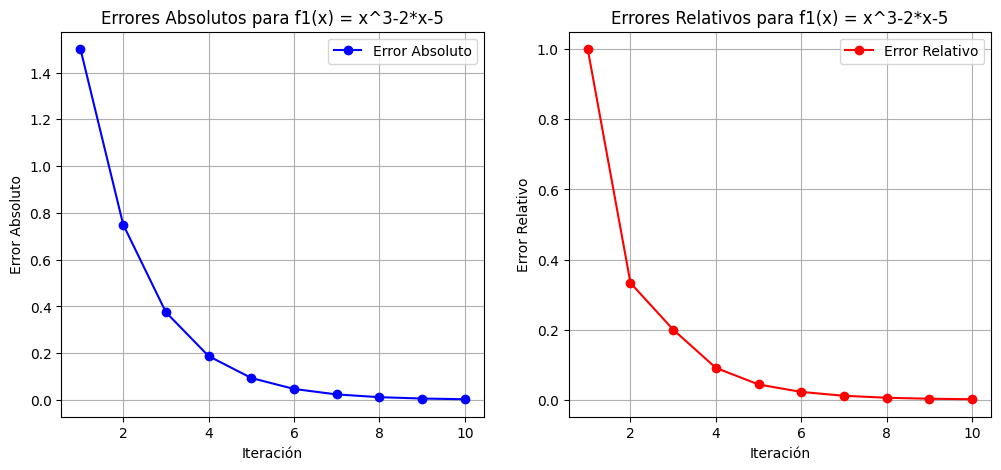

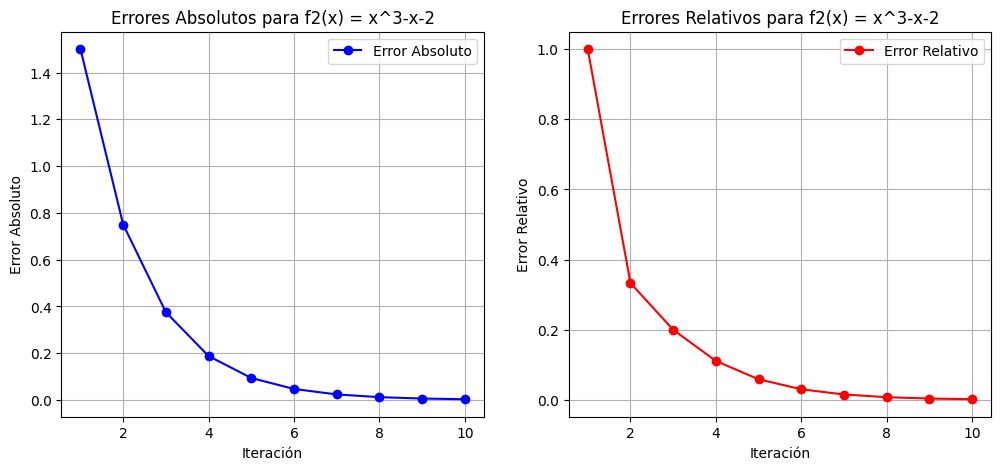

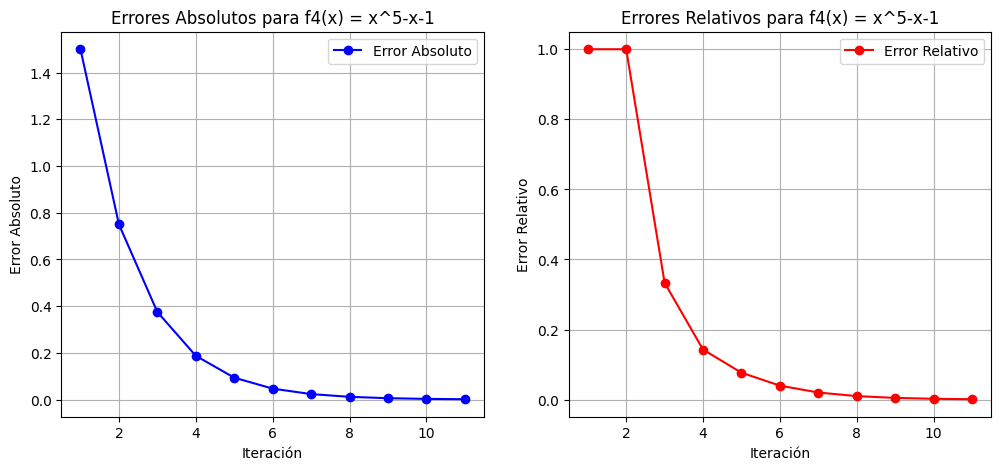

In [96]:
#Defino mi intervalo inicial
iterations = 15
tolerancia = 1e-2

#ahora realizo el metodo de biseccion para las funnciones, con las iteraciones que puse
for nombre, funcion in Funciones.items():
  a, b = 3, -3
  print(f"Intervalo inicial: [{a}, {b}]")

  if sp.N(funcion.subs(x, a)) * sp.N(funcion.subs(x, b)) >= 0:
        print(f"No se puede aplicar el método de bisección a {nombre} en el intervalo [{a}, {b}]")
        continue

  print(f"\nAnalizando {nombre} en el intervalo inicial: [{a}, {b}]")
  errores_absolutos = []
  errores_relativos = []


  prev_c = None
  # aplico el método de bisección
  for i in range(iterations):
      c = (a + b) / 2  #punto medio
      fc = funcion.subs(x, c)

      print(f"Iteración {i + 1}:")
      print(f" - Punto medio c = {c:.4f}")
      print(f" - f(c) = {fc:.4f}")

        # calculo el error absoluto
      if prev_c is not None:  # Verifica que prev_c esté definido
            error_absoluto = abs(c - prev_c)
            errores_absolutos.append(error_absoluto)

            # Calculo el error relativo
            error_relativo = abs((c - prev_c) / c) if c != 0 else float('inf')
            errores_relativos.append(error_relativo)

      #tolerancia
      # verifico si la tolerancia se alcanza
      if abs(fc) < tolerancia:
          print(f"Se encontró una raíz aproximada: {c:.4f} en la iteración {i + 1}")
          break

      # actualizo el intervalo
      if funcion.subs(x, a) * fc < 0:  # si hay signos opuestos entonces hay una raiz entre a y c
          b = c
      else:  # hay raíz entre c y b
          a = c
      prev_c = c


  print(f"Nuevo intervalo: [{a:.4f}, {b:.4f}]")

  print(f"Después de {iterations} iteraciones, la raíz aproximada es: {c:.4f}\n")

  #Grafico el error absoluto y el relativo despues de biseccion
  #Primero el error abssolut
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(range(1, len(errores_absolutos) + 1), errores_absolutos, marker='o', color='b', label='Error Absoluto')
  plt.title(f'Errores Absolutos para {nombre}')
  plt.xlabel('Iteración')
  plt.ylabel('Error Absoluto')
  plt.grid(True)
  plt.legend()

  #Grafico ahora el relativo
  plt.subplot(1, 2, 2)
  plt.plot(range(1, len(errores_relativos) + 1), errores_relativos, marker='o', color='r', label='Error Relativo')
  plt.title(f'Errores Relativos para {nombre}')
  plt.xlabel('Iteración')
  plt.ylabel('Error Relativo')
  plt.grid(True)
  plt.legend()

###Tolerancia 1e-5

Intervalo inicial: [3, -3]

Analizando f1(x) = x^3-2*x-5 en el intervalo inicial: [3, -3]
Iteración 1:
 - Punto medio c = 0.0000
 - f(c) = -5.0000
Iteración 2:
 - Punto medio c = 1.5000
 - f(c) = -4.6250
Iteración 3:
 - Punto medio c = 2.2500
 - f(c) = 1.8906
Iteración 4:
 - Punto medio c = 1.8750
 - f(c) = -2.1582
Iteración 5:
 - Punto medio c = 2.0625
 - f(c) = -0.3513
Iteración 6:
 - Punto medio c = 2.1562
 - f(c) = 0.7128
Iteración 7:
 - Punto medio c = 2.1094
 - f(c) = 0.1668
Iteración 8:
 - Punto medio c = 2.0859
 - f(c) = -0.0957
Iteración 9:
 - Punto medio c = 2.0977
 - f(c) = 0.0347
Iteración 10:
 - Punto medio c = 2.0918
 - f(c) = -0.0307
Iteración 11:
 - Punto medio c = 2.0947
 - f(c) = 0.0020
Iteración 12:
 - Punto medio c = 2.0933
 - f(c) = -0.0144
Iteración 13:
 - Punto medio c = 2.0940
 - f(c) = -0.0062
Iteración 14:
 - Punto medio c = 2.0944
 - f(c) = -0.0021
Iteración 15:
 - Punto medio c = 2.0945
 - f(c) = -0.0001
Nuevo intervalo: [2.0947, 2.0945]
Después de 15 iterac

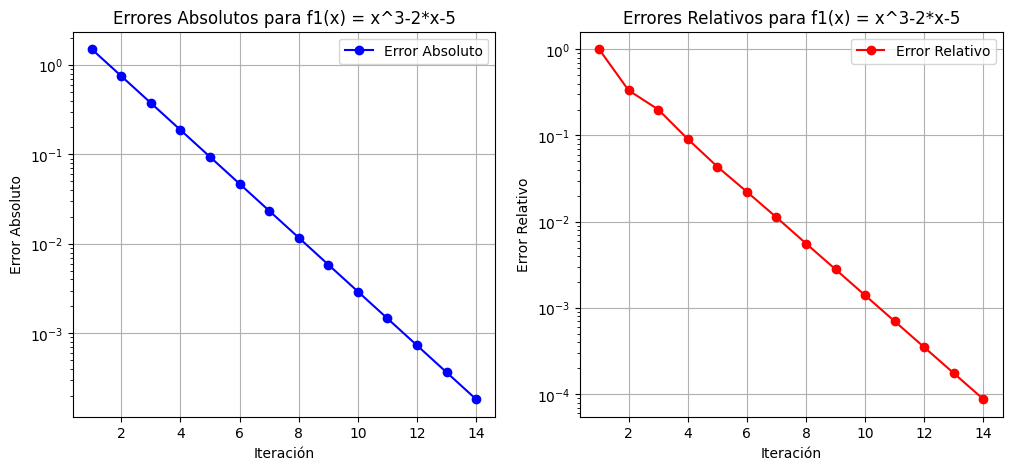

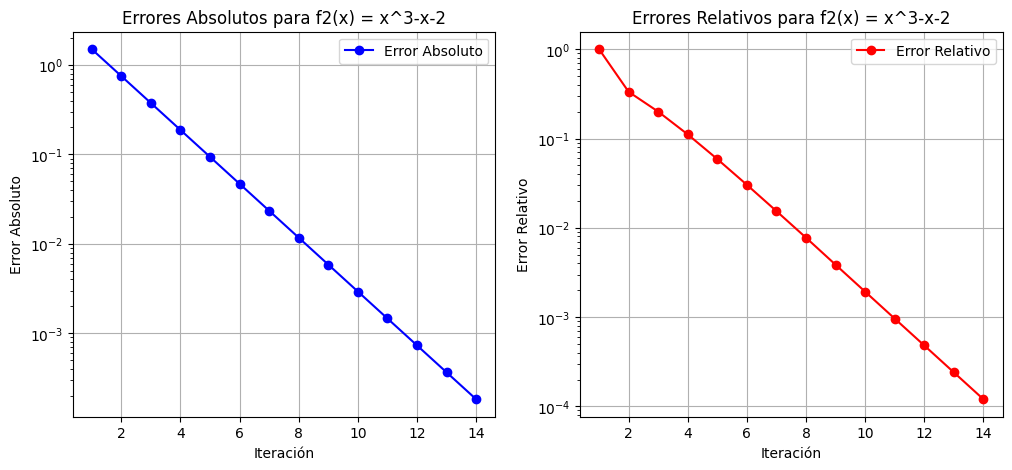

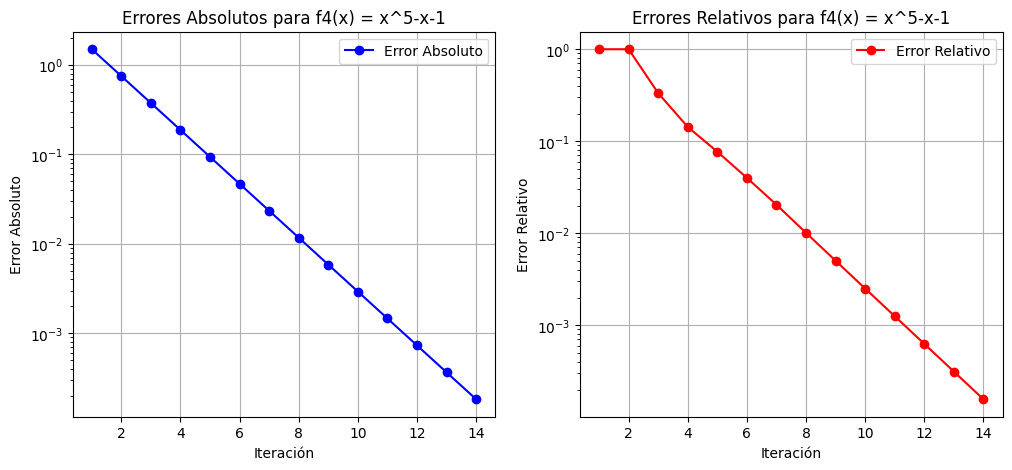

In [97]:
#Defino mi intervalo inicial
iterations = 15
tolerancia = 1e-5

#ahora realizo el metodo de biseccion para las funnciones, con las iteraciones que puse
for nombre, funcion in Funciones.items():
  a, b = 3, -3
  print(f"Intervalo inicial: [{a}, {b}]")

  if sp.N(funcion.subs(x, a)) * sp.N(funcion.subs(x, b)) >= 0:
        print(f"No se puede aplicar el método de bisección a {nombre} en el intervalo [{a}, {b}]")
        continue

  print(f"\nAnalizando {nombre} en el intervalo inicial: [{a}, {b}]")
  errores_absolutos = []
  errores_relativos = []


  prev_c = None
  # aplico el método de bisección
  for i in range(iterations):
      c = (a + b) / 2  #punto medio
      fc = funcion.subs(x, c)

      print(f"Iteración {i + 1}:")
      print(f" - Punto medio c = {c:.4f}")
      print(f" - f(c) = {fc:.4f}")

        # calculo el error absoluto
      if prev_c is not None:  # Verifica que prev_c esté definido
            error_absoluto = abs(c - prev_c)
            errores_absolutos.append(error_absoluto)

            # Calculo el error relativo
            error_relativo = abs((c - prev_c) / c) if c != 0 else float('inf')
            errores_relativos.append(error_relativo)

      #tolerancia
      # verifico si la tolerancia se alcanza
      if abs(fc) < tolerancia:
          print(f"Se encontró una raíz aproximada: {c:.4f} en la iteración {i + 1}")
          break

      # actualizo el intervalo
      if funcion.subs(x, a) * fc < 0:  # si hay signos opuestos entonces hay una raiz entre a y c
          b = c
      else:  # hay raíz entre c y b
          a = c
      prev_c = c


  print(f"Nuevo intervalo: [{a:.4f}, {b:.4f}]")

  print(f"Después de {iterations} iteraciones, la raíz aproximada es: {c:.4f}\n")

  #Grafico el error absoluto y el relativo despues de biseccion
  #Primero el error abssolut
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(range(1, len(errores_absolutos) + 1), errores_absolutos, marker='o', color='b', label='Error Absoluto')
  plt.yscale('log')
  plt.title(f'Errores Absolutos para {nombre}')
  plt.xlabel('Iteración')
  plt.ylabel('Error Absoluto')
  plt.grid(True)
  plt.legend()

  #Grafico ahora el relativo
  plt.subplot(1, 2, 2)
  plt.plot(range(1, len(errores_relativos) + 1), errores_relativos, marker='o', color='r', label='Error Relativo')
  plt.yscale('log')
  plt.title(f'Errores Relativos para {nombre}')
  plt.xlabel('Iteración')
  plt.ylabel('Error Relativo')
  plt.grid(True)
  plt.legend()

###Tolerancia 1e-7

Intervalo inicial: [3, -3]

Analizando f1(x) = x^3-2*x-5 en el intervalo inicial: [3, -3]
Iteración 1:
 - Punto medio c = 0.0000
 - f(c) = -5.0000
Iteración 2:
 - Punto medio c = 1.5000
 - f(c) = -4.6250
Iteración 3:
 - Punto medio c = 2.2500
 - f(c) = 1.8906
Iteración 4:
 - Punto medio c = 1.8750
 - f(c) = -2.1582
Iteración 5:
 - Punto medio c = 2.0625
 - f(c) = -0.3513
Iteración 6:
 - Punto medio c = 2.1562
 - f(c) = 0.7128
Iteración 7:
 - Punto medio c = 2.1094
 - f(c) = 0.1668
Iteración 8:
 - Punto medio c = 2.0859
 - f(c) = -0.0957
Iteración 9:
 - Punto medio c = 2.0977
 - f(c) = 0.0347
Iteración 10:
 - Punto medio c = 2.0918
 - f(c) = -0.0307
Iteración 11:
 - Punto medio c = 2.0947
 - f(c) = 0.0020
Iteración 12:
 - Punto medio c = 2.0933
 - f(c) = -0.0144
Iteración 13:
 - Punto medio c = 2.0940
 - f(c) = -0.0062
Iteración 14:
 - Punto medio c = 2.0944
 - f(c) = -0.0021
Iteración 15:
 - Punto medio c = 2.0945
 - f(c) = -0.0001
Nuevo intervalo: [2.0947, 2.0945]
Después de 15 iterac

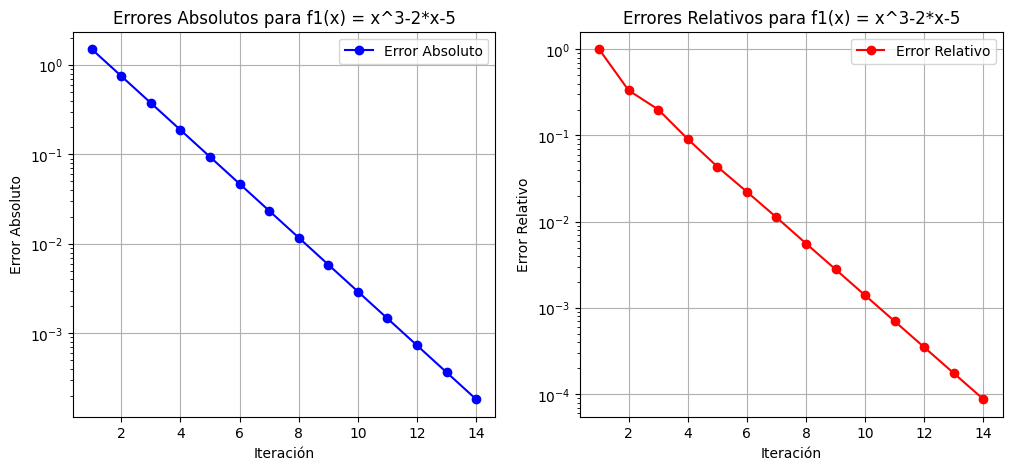

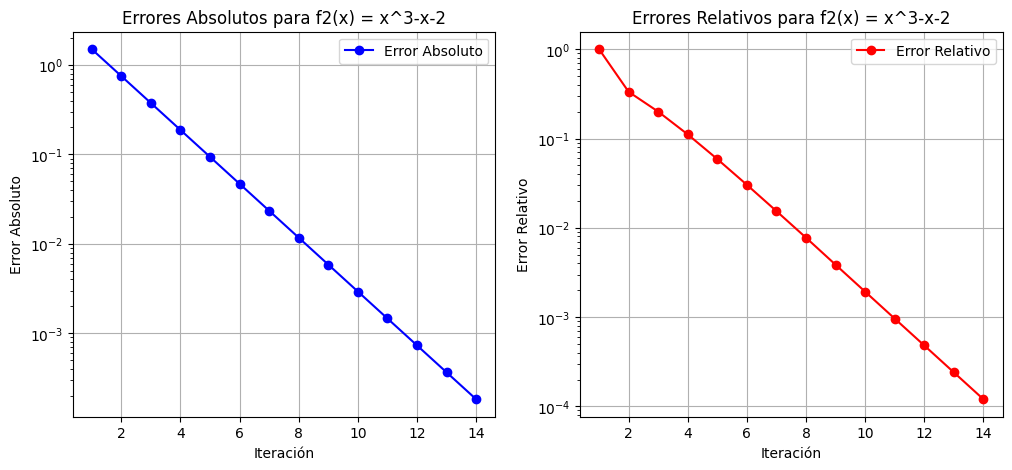

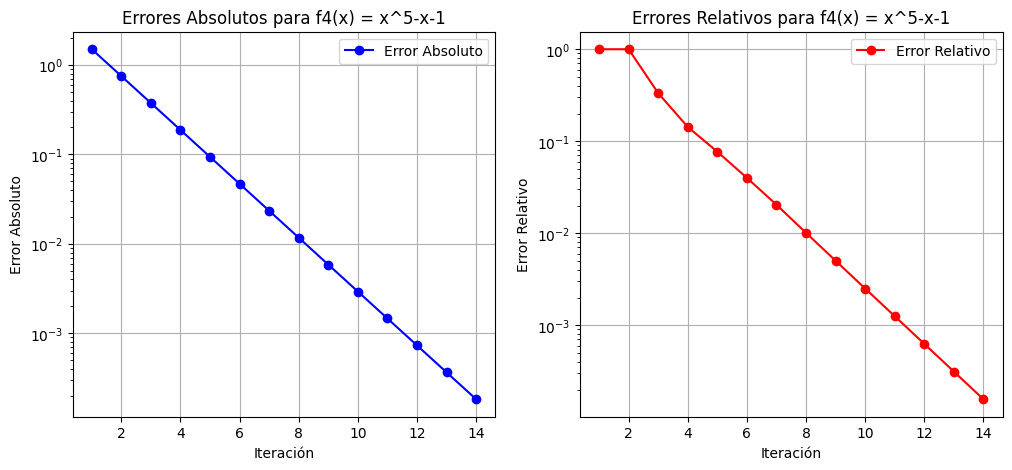

In [98]:
#Defino mi intervalo inicial
iterations = 15
tolerancia = 1e-7

#ahora realizo el metodo de biseccion para las funnciones, con las iteraciones que puse
for nombre, funcion in Funciones.items():
  a, b = 3, -3
  print(f"Intervalo inicial: [{a}, {b}]")

  if sp.N(funcion.subs(x, a)) * sp.N(funcion.subs(x, b)) >= 0:
        print(f"No se puede aplicar el método de bisección a {nombre} en el intervalo [{a}, {b}]")
        continue

  print(f"\nAnalizando {nombre} en el intervalo inicial: [{a}, {b}]")
  errores_absolutos = []
  errores_relativos = []


  prev_c = None
  # aplico el método de bisección
  for i in range(iterations):
      c = (a + b) / 2  #punto medio
      fc = funcion.subs(x, c)

      print(f"Iteración {i + 1}:")
      print(f" - Punto medio c = {c:.4f}")
      print(f" - f(c) = {fc:.4f}")

        # calculo el error absoluto
      if prev_c is not None:  # Verifica que prev_c esté definido
            error_absoluto = abs(c - prev_c)
            errores_absolutos.append(error_absoluto)

            # Calculo el error relativo
            error_relativo = abs((c - prev_c) / c) if c != 0 else float('inf')
            errores_relativos.append(error_relativo)

      #tolerancia
      # verifico si la tolerancia se alcanza
      if abs(fc) < tolerancia:
          print(f"Se encontró una raíz aproximada: {c:.4f} en la iteración {i + 1}")
          break

      # actualizo el intervalo
      if funcion.subs(x, a) * fc < 0:  # si hay signos opuestos entonces hay una raiz entre a y c
          b = c
      else:  # hay raíz entre c y b
          a = c
      prev_c = c


  print(f"Nuevo intervalo: [{a:.4f}, {b:.4f}]")

  print(f"Después de {iterations} iteraciones, la raíz aproximada es: {c:.4f}\n")

  #Grafico el error absoluto y el relativo despues de biseccion
  #Primero el error abssolut
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(range(1, len(errores_absolutos) + 1), errores_absolutos, marker='o', color='b', label='Error Absoluto')
  plt.yscale('log')
  plt.title(f'Errores Absolutos para {nombre}')
  plt.xlabel('Iteración')
  plt.ylabel('Error Absoluto')
  plt.grid(True)
  plt.legend()

  #Grafico ahora el relativo
  plt.subplot(1, 2, 2)
  plt.plot(range(1, len(errores_relativos) + 1), errores_relativos, marker='o', color='r', label='Error Relativo')
  plt.yscale('log')
  plt.title(f'Errores Relativos para {nombre}')
  plt.xlabel('Iteración')
  plt.ylabel('Error Relativo')
  plt.grid(True)
  plt.legend()

###Tolerancia 1e-12

Intervalo inicial: [3, -3]

Analizando f1(x) = x^3-2*x-5 en el intervalo inicial: [3, -3]
Iteración 1:
 - Punto medio c = 0.0000
 - f(c) = -5.0000
Iteración 2:
 - Punto medio c = 1.5000
 - f(c) = -4.6250
Iteración 3:
 - Punto medio c = 2.2500
 - f(c) = 1.8906
Iteración 4:
 - Punto medio c = 1.8750
 - f(c) = -2.1582
Iteración 5:
 - Punto medio c = 2.0625
 - f(c) = -0.3513
Iteración 6:
 - Punto medio c = 2.1562
 - f(c) = 0.7128
Iteración 7:
 - Punto medio c = 2.1094
 - f(c) = 0.1668
Iteración 8:
 - Punto medio c = 2.0859
 - f(c) = -0.0957
Iteración 9:
 - Punto medio c = 2.0977
 - f(c) = 0.0347
Iteración 10:
 - Punto medio c = 2.0918
 - f(c) = -0.0307
Iteración 11:
 - Punto medio c = 2.0947
 - f(c) = 0.0020
Iteración 12:
 - Punto medio c = 2.0933
 - f(c) = -0.0144
Iteración 13:
 - Punto medio c = 2.0940
 - f(c) = -0.0062
Iteración 14:
 - Punto medio c = 2.0944
 - f(c) = -0.0021
Iteración 15:
 - Punto medio c = 2.0945
 - f(c) = -0.0001
Nuevo intervalo: [2.0947, 2.0945]
Después de 15 iterac

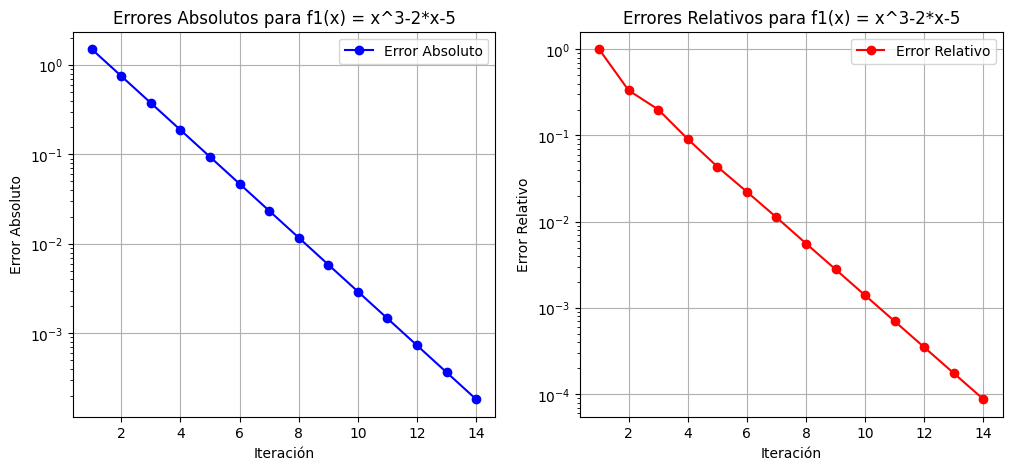

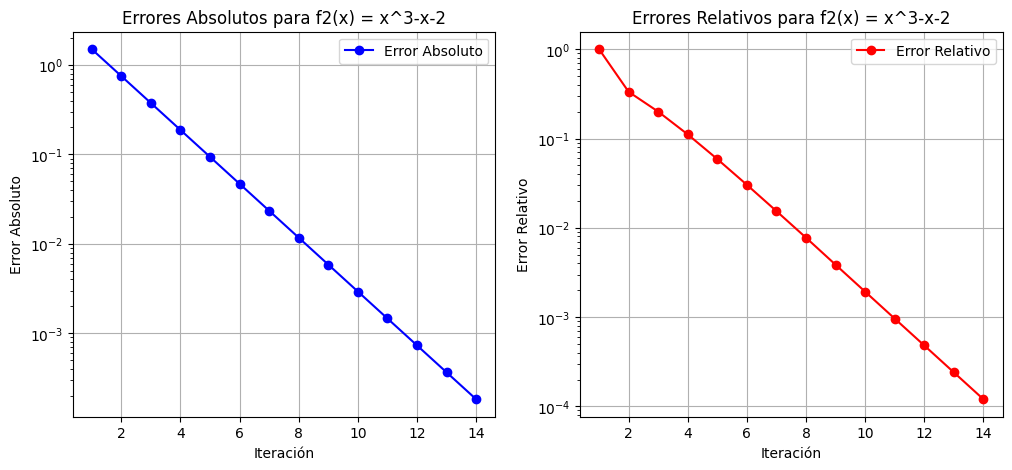

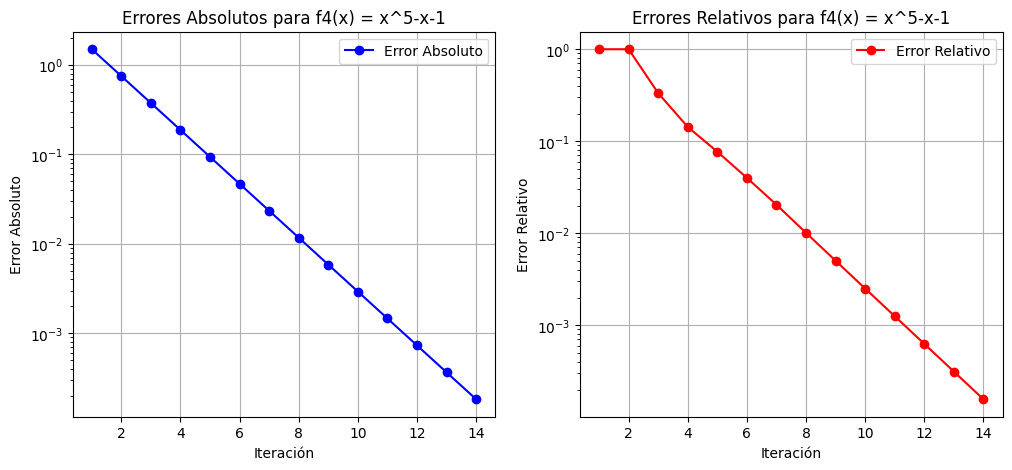

In [99]:
#Defino mi intervalo inicial
iterations = 15
tolerancia = 1e-12

#ahora realizo el metodo de biseccion para las funnciones, con las iteraciones que puse
for nombre, funcion in Funciones.items():
  a, b = 3, -3
  print(f"Intervalo inicial: [{a}, {b}]")

  if sp.N(funcion.subs(x, a)) * sp.N(funcion.subs(x, b)) >= 0:
        print(f"No se puede aplicar el método de bisección a {nombre} en el intervalo [{a}, {b}]")
        continue

  print(f"\nAnalizando {nombre} en el intervalo inicial: [{a}, {b}]")
  errores_absolutos = []
  errores_relativos = []


  prev_c = None
  # aplico el método de bisección
  for i in range(iterations):
      c = (a + b) / 2  #punto medio
      fc = funcion.subs(x, c)

      print(f"Iteración {i + 1}:")
      print(f" - Punto medio c = {c:.4f}")
      print(f" - f(c) = {fc:.4f}")

        # calculo el error absoluto
      if prev_c is not None:  # Verifica que prev_c esté definido
            error_absoluto = abs(c - prev_c)
            errores_absolutos.append(error_absoluto)

            # Calculo el error relativo
            error_relativo = abs((c - prev_c) / c) if c != 0 else float('inf')
            errores_relativos.append(error_relativo)

      #tolerancia
      # verifico si la tolerancia se alcanza
      if abs(fc) < tolerancia:
          print(f"Se encontró una raíz aproximada: {c:.4f} en la iteración {i + 1}")
          break

      # actualizo el intervalo
      if funcion.subs(x, a) * fc < 0:  # si hay signos opuestos entonces hay una raiz entre a y c
          b = c
      else:  # hay raíz entre c y b
          a = c
      prev_c = c


  print(f"Nuevo intervalo: [{a:.4f}, {b:.4f}]")

  print(f"Después de {iterations} iteraciones, la raíz aproximada es: {c:.4f}\n")

  #Grafico el error absoluto y el relativo despues de biseccion
  #Primero el error abssolut
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(range(1, len(errores_absolutos) + 1), errores_absolutos, marker='o', color='b', label='Error Absoluto')
  plt.yscale('log')
  plt.title(f'Errores Absolutos para {nombre}')
  plt.xlabel('Iteración')
  plt.ylabel('Error Absoluto')
  plt.grid(True)
  plt.legend()

  #Grafico ahora el relativo
  plt.subplot(1, 2, 2)
  plt.plot(range(1, len(errores_relativos) + 1), errores_relativos, marker='o', color='r', label='Error Relativo')
  plt.yscale('log')
  plt.title(f'Errores Relativos para {nombre}')
  plt.xlabel('Iteración')
  plt.ylabel('Error Relativo')
  plt.grid(True)
  plt.legend()

##Punto c

###Tolerancia 1e-2

Procesando f1(x) con g(x) = (2*x + 5)**0.333333333333333
-Raíz aprox: 2.09355411110898


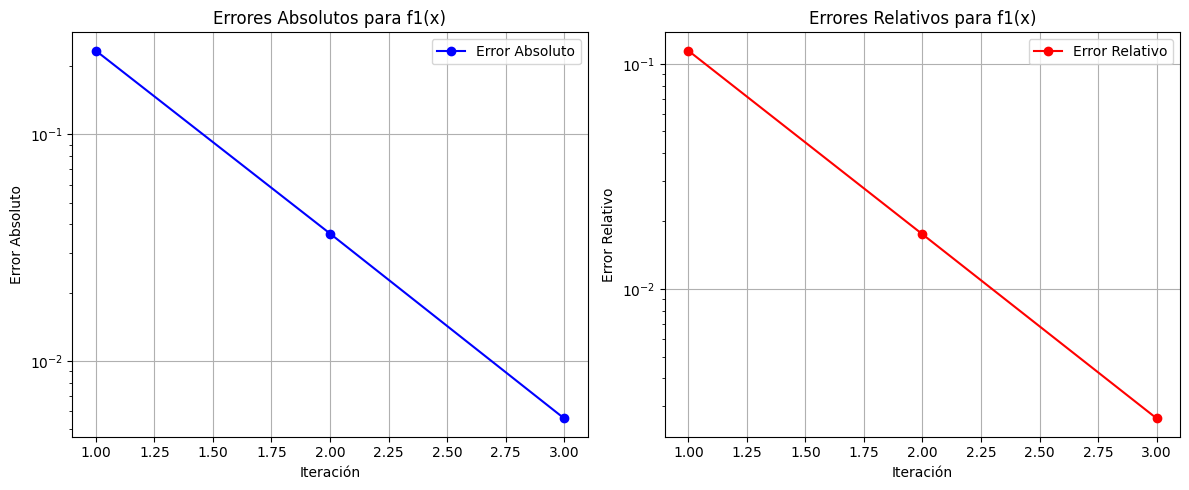

Procesando f2(x) con g(x) = (x + 2)**0.333333333333333
-Raíz aprox: 1.52088023126502


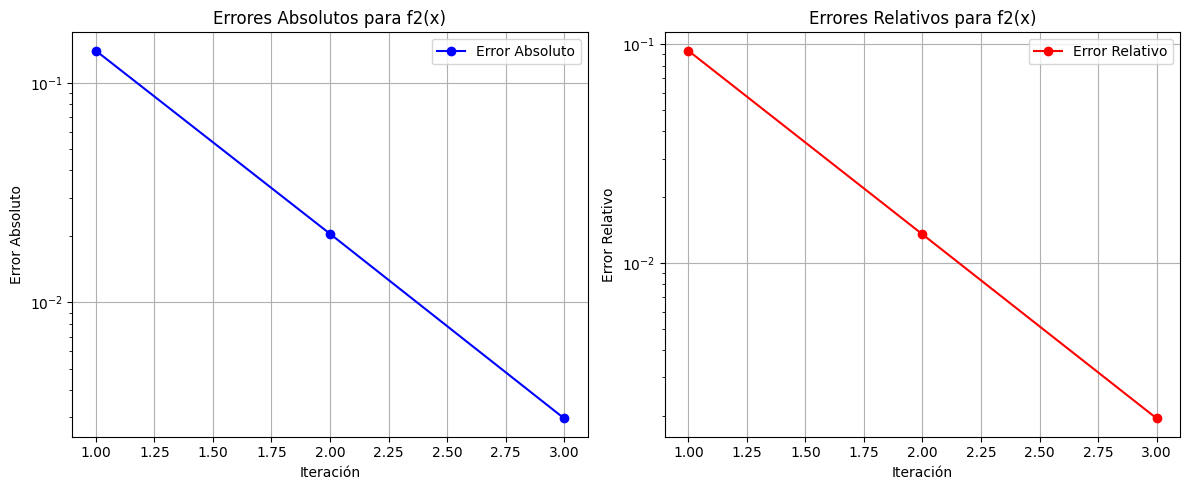

Procesando f3(x) con g(x) = 1.49534878122122*(x**2)**0.25
-Raíz aprox: 2.22953587591616


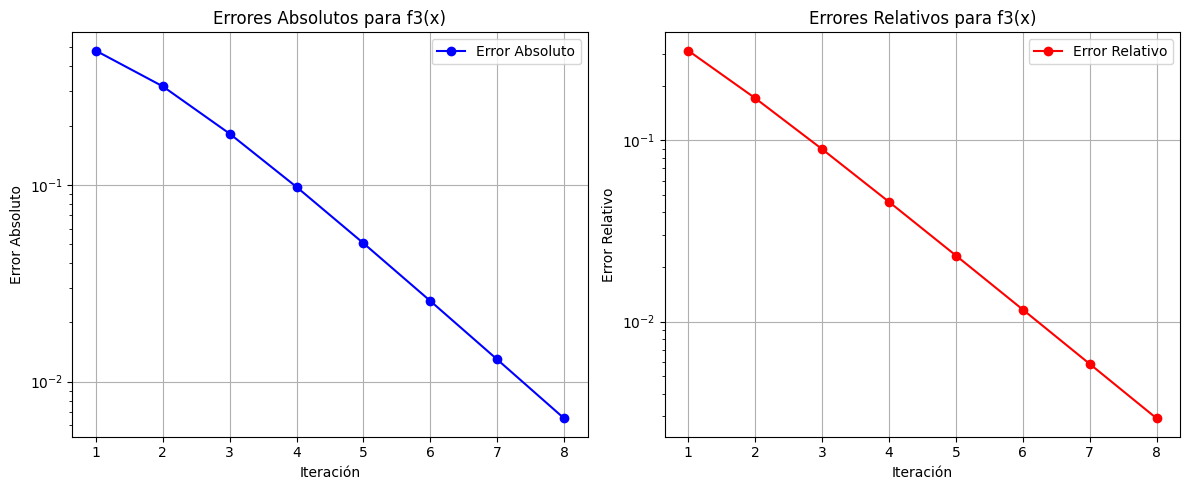

Procesando f4(x) con g(x) = (x + 1)**0.2
-Raíz aprox: 1.16632615978979


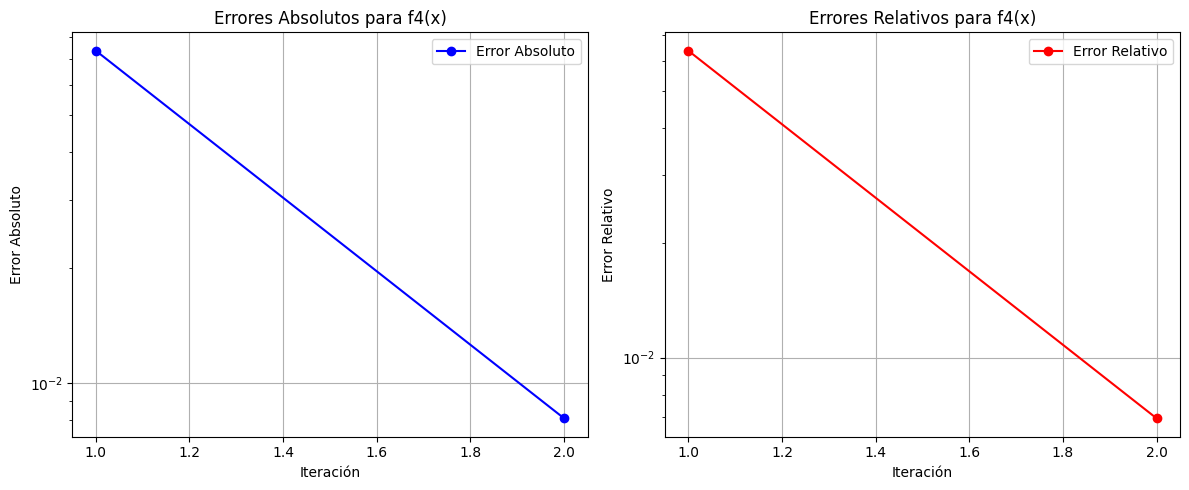

Procesando f5(x) con g(x) = exp(x)/4
-Raíz aprox: 0.360008991374613


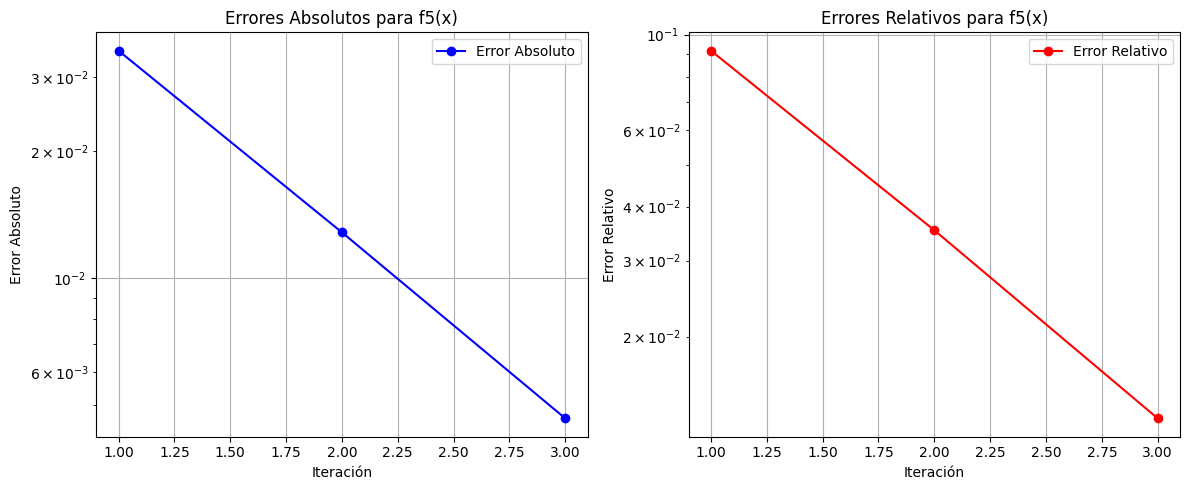

In [100]:
Funciones_g = {
    "f1(x)": (2*x + 5)**(1/3),
    "f2(x)": (x + 2)**(1/3),
    "f3(x)": (5*x**2)**(1/4), #ya
    "f4(x)": (x + 1)**(1/5),
    "f5(x)": sp.exp(x) / 4  # ya solucione ya, lo que pasaba es que con otra forma que yo habia sacado la g(x) no me daban las raices, ahora que transforme de otra fomra, si me da
}

maximas_iteraciones = 50
toleration = 1e-2

def punto_fijo(g, x0):
    iteraciones = []
    errores_absolutos = []
    errores_relativos = []

    for i in range(maximas_iteraciones):
        x1 = g.evalf(subs={x: x0})
        iteraciones.append((i + 1, x0, x1))

        #CALCILO MIS ERRORES
        if i > 0:
            error_absoluto = abs(x1 - x0)
            errores_absolutos.append(error_absoluto)

            error_relativo = abs((x1 - x0) / x1) if x1 != 0 else float('inf')
            errores_relativos.append(error_relativo)

        if abs(x1 - x0) < toleration:
            return x1, iteraciones, errores_absolutos, errores_relativos  #que me devuelva la raiz arpox y las iteraciones
        x0 = x1  # actualizo el valor de x

    return None, iteraciones, errores_absolutos, errores_relativos #si no se encuentra la raiz en el nro max de iteraciones

#entonces ahora lo que voy a hacer es que voy a hacer este metodo pero para todas mis funciones dentro d mi dicccionario
for nombre, g in Funciones_g.items():
    print(f"Procesando {nombre} con g(x) = {g}")

    X0 = 0.5
    raiz, iteraciones, errores_absolutos, errores_relativos = punto_fijo(g, X0)

    if raiz is not None:
      print(f"-Raíz aprox: {raiz}")
    else:
      print(f"-No se encontro una raíz en el número máximo de iteraciones")

    #Grafico los errores
    plt.figure(figsize=(12, 5))

    #error abs
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(errores_absolutos) + 1), errores_absolutos, marker='o', color='b', label='Error Absoluto')
    plt.yscale('log')
    plt.title(f'Errores Absolutos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Absoluto')
    plt.grid(True)
    plt.legend()

    #error relat
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(errores_relativos) + 1), errores_relativos, marker='o', color='r', label='Error Relativo')
    plt.yscale('log')
    plt.title(f'Errores Relativos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Relativo')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    #me estan quedando raros los graficos de estos edit:mentira, yo estaba haciendo cualquier cosa

###Tolerancia 1e-5

Procesando f1(x) con g(x) = (2*x + 5)**0.333333333333333
-Raíz aprox: 2.09455094967884


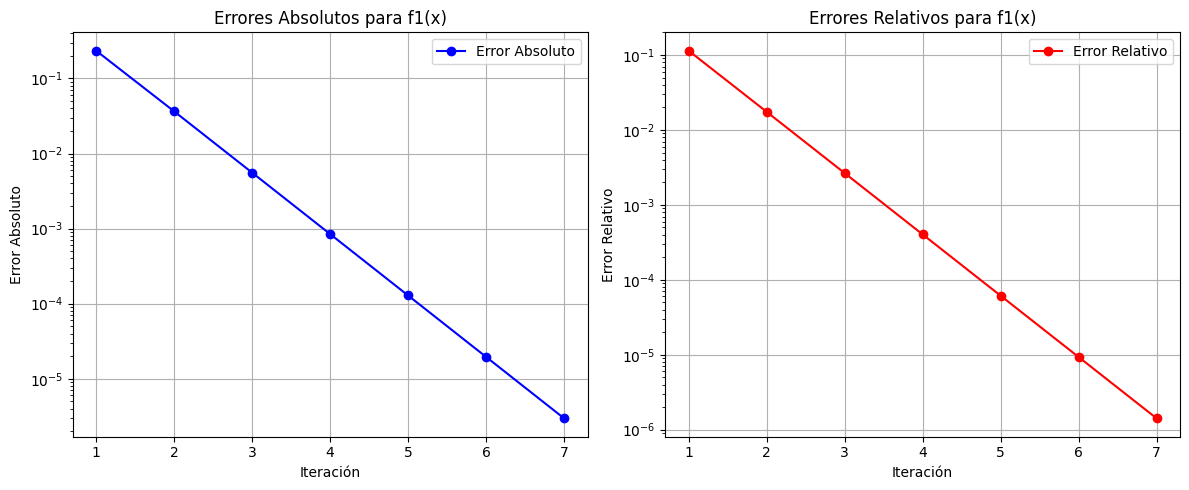

Procesando f2(x) con g(x) = (x + 2)**0.333333333333333
-Raíz aprox: 1.52137821487382


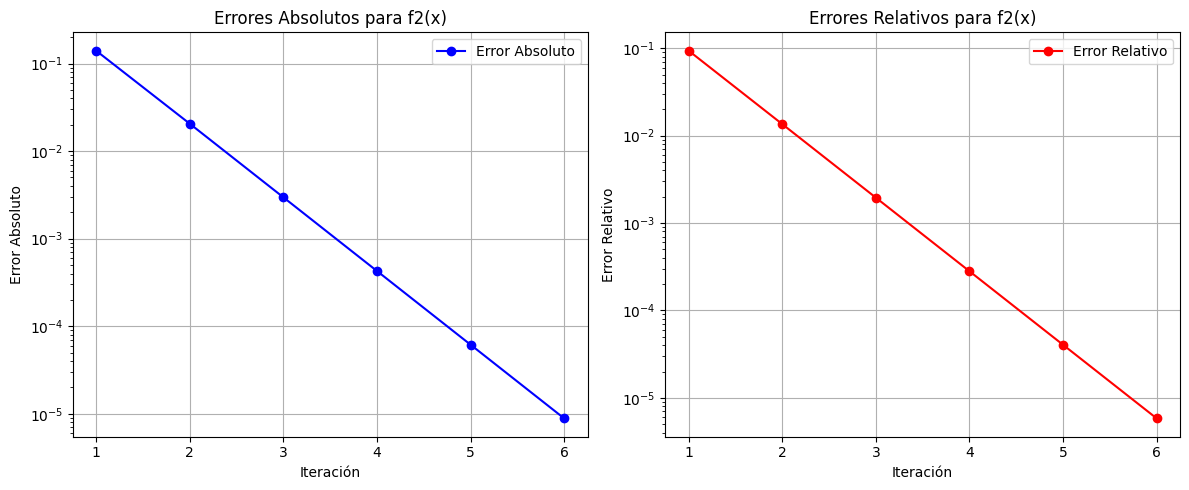

Procesando f3(x) con g(x) = 1.49534878122122*(x**2)**0.25
-Raíz aprox: 2.23606158916796


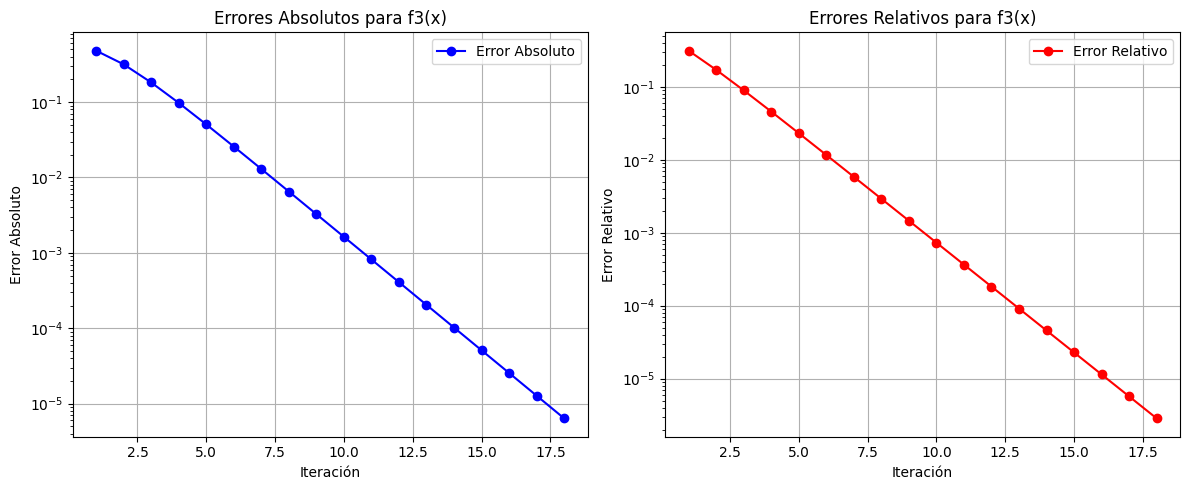

Procesando f4(x) con g(x) = (x + 1)**0.2
-Raíz aprox: 1.16730384658057


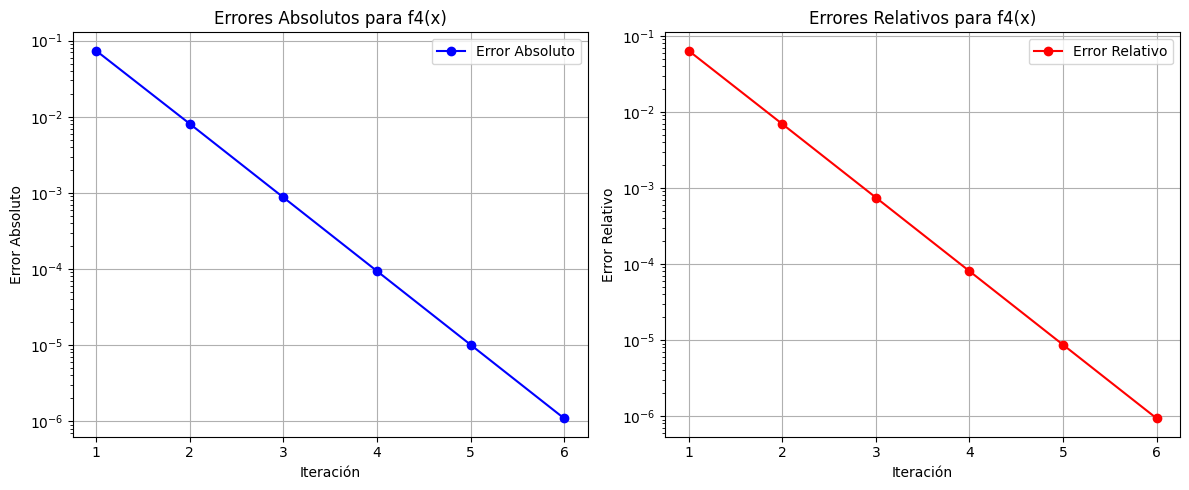

Procesando f5(x) con g(x) = exp(x)/4
-Raíz aprox: 0.357408398807813


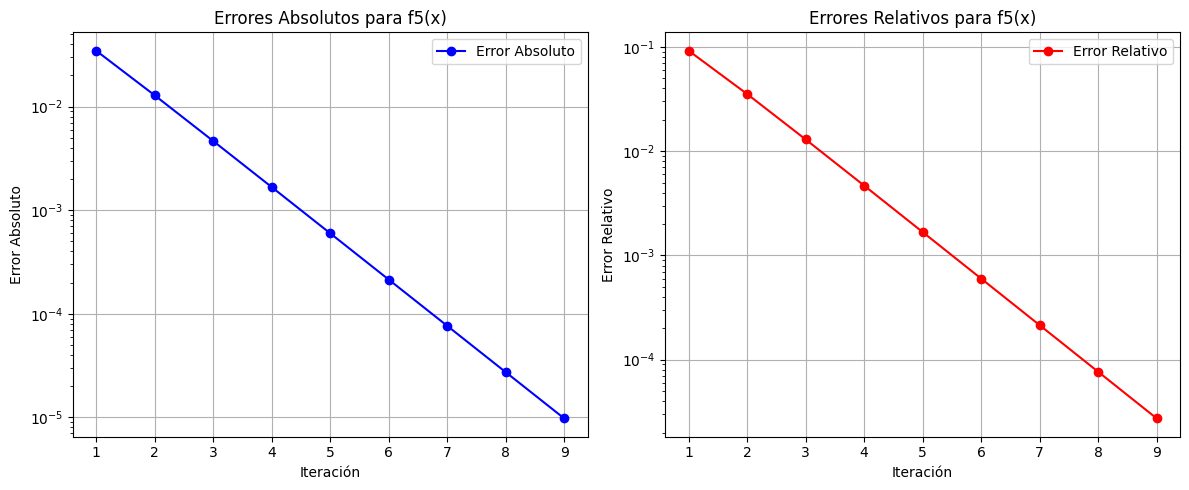

In [101]:
Funciones_g = {
    "f1(x)": (2*x + 5)**(1/3),
    "f2(x)": (x + 2)**(1/3),
    "f3(x)": (5*x**2)**(1/4), #ya
    "f4(x)": (x + 1)**(1/5),
    "f5(x)": sp.exp(x) / 4  # ya solucione ya, lo que pasaba es que con otra forma que yo habia sacado la g(x) no me daban las raices, ahora que transforme de otra fomra, si me da
}

maximas_iteraciones = 50
toleration = 1e-5

def punto_fijo(g, x0):
    iteraciones = []
    errores_absolutos = []
    errores_relativos = []

    for i in range(maximas_iteraciones):
        x1 = g.evalf(subs={x: x0})
        iteraciones.append((i + 1, x0, x1))

        #CALCILO MIS ERRORES
        if i > 0:
            error_absoluto = abs(x1 - x0)
            errores_absolutos.append(error_absoluto)

            error_relativo = abs((x1 - x0) / x1) if x1 != 0 else float('inf')
            errores_relativos.append(error_relativo)

        if abs(x1 - x0) < toleration:
            return x1, iteraciones, errores_absolutos, errores_relativos  #que me devuelva la raiz arpox y las iteraciones
        x0 = x1  # actualizo el valor de x

    return None, iteraciones, errores_absolutos, errores_relativos #si no se encuentra la raiz en el nro max de iteraciones

#entonces ahora lo que voy a hacer es que voy a hacer este metodo pero para todas mis funciones dentro d mi dicccionario
for nombre, g in Funciones_g.items():
    print(f"Procesando {nombre} con g(x) = {g}")

    X0 = 0.5
    raiz, iteraciones, errores_absolutos, errores_relativos = punto_fijo(g, X0)

    if raiz is not None:
      print(f"-Raíz aprox: {raiz}")
    else:
      print(f"-No se encontro una raíz en el número máximo de iteraciones")

    #Grafico los errores
    plt.figure(figsize=(12, 5))

    #error abs
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(errores_absolutos) + 1), errores_absolutos, marker='o', color='b', label='Error Absoluto')
    plt.yscale('log')
    plt.title(f'Errores Absolutos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Absoluto')
    plt.grid(True)
    plt.legend()

    #error relat
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(errores_relativos) + 1), errores_relativos, marker='o', color='r', label='Error Relativo')
    plt.yscale('log')
    plt.title(f'Errores Relativos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Relativo')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

###Tolerancia 1e-7

Procesando f1(x) con g(x) = (2*x + 5)**0.333333333333333
-Raíz aprox: 2.09455146926077


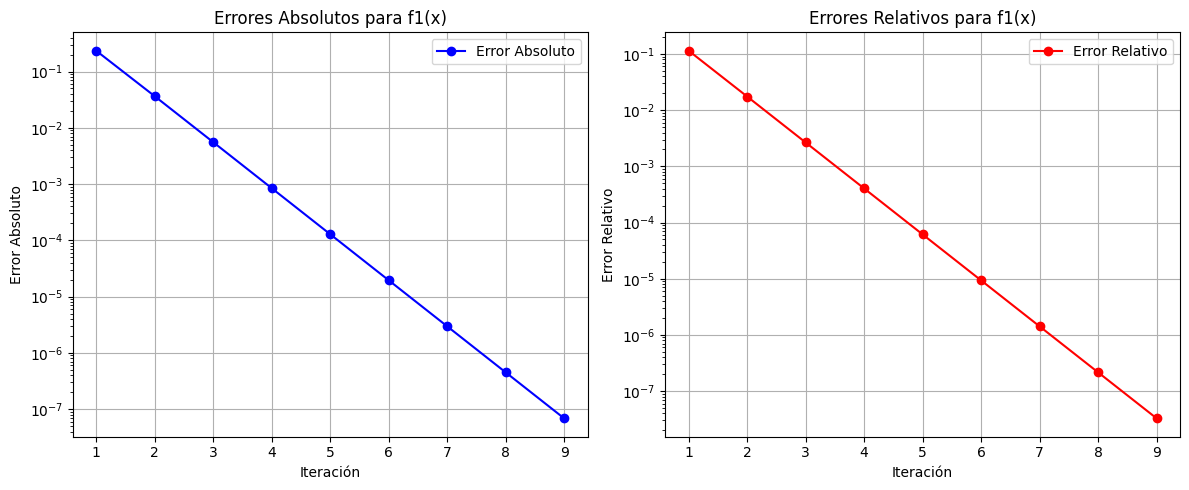

Procesando f2(x) con g(x) = (x + 2)**0.333333333333333
-Raíz aprox: 1.52137970234842


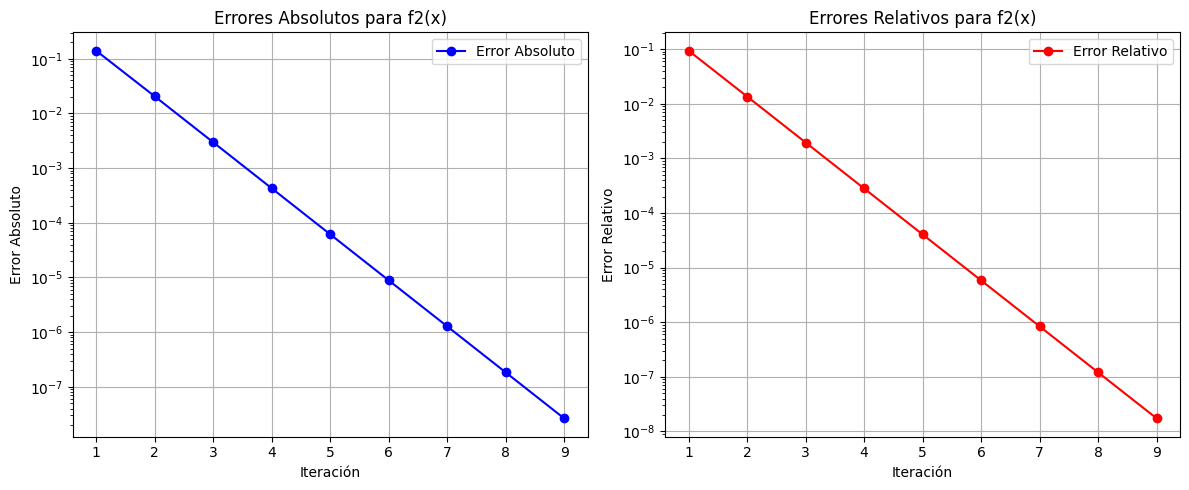

Procesando f3(x) con g(x) = 1.49534878122122*(x**2)**0.25
-Raíz aprox: 2.23606787768196


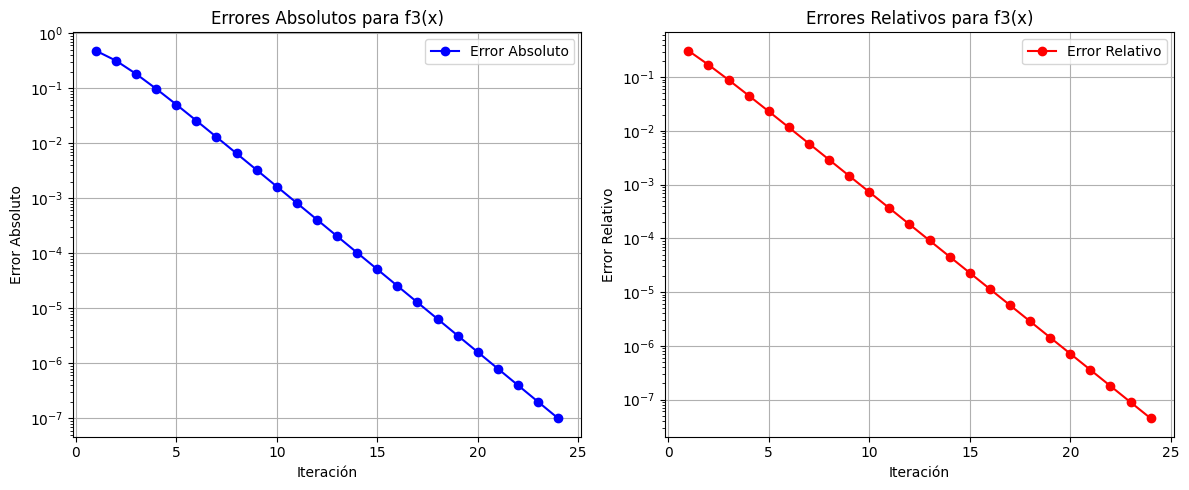

Procesando f4(x) con g(x) = (x + 1)**0.2
-Raíz aprox: 1.16730397673346


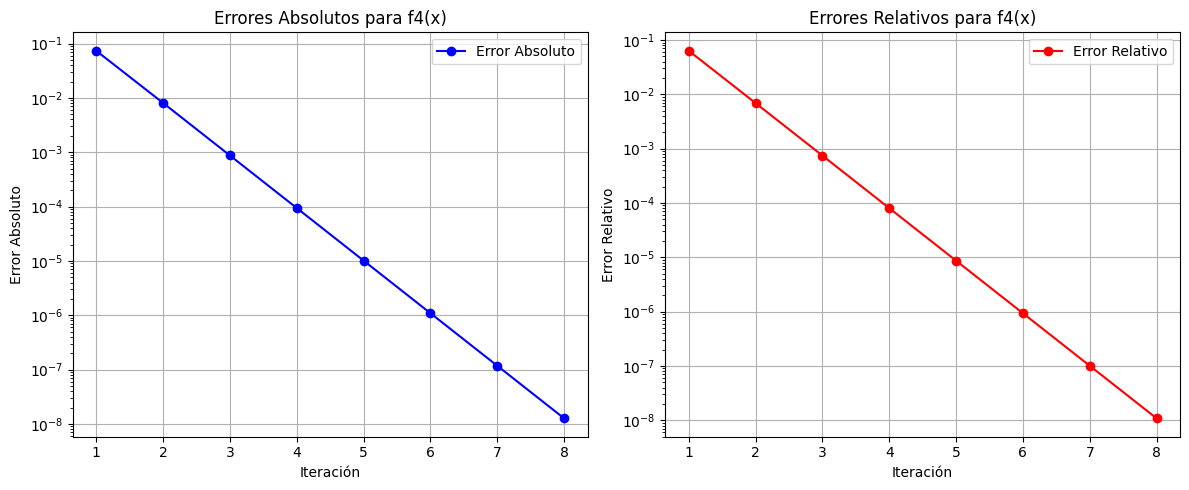

Procesando f5(x) con g(x) = exp(x)/4
-Raíz aprox: 0.357402987920960


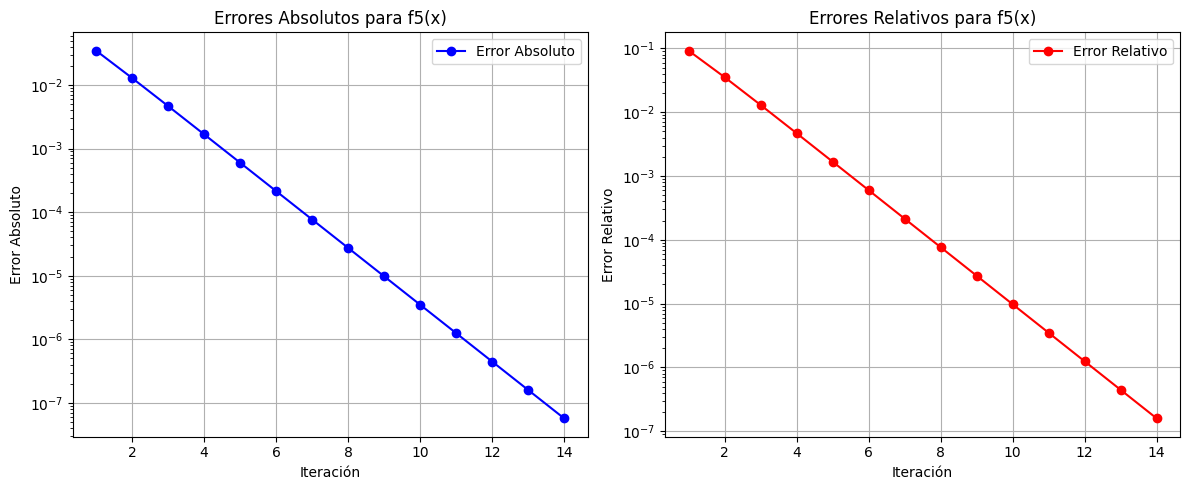

In [102]:
Funciones_g = {
    "f1(x)": (2*x + 5)**(1/3),
    "f2(x)": (x + 2)**(1/3),
    "f3(x)": (5*x**2)**(1/4), #ya
    "f4(x)": (x + 1)**(1/5),
    "f5(x)": sp.exp(x) / 4  # ya solucione ya, lo que pasaba es que con otra forma que yo habia sacado la g(x) no me daban las raices, ahora que transforme de otra fomra, si me da
}

maximas_iteraciones = 50
toleration = 1e-7

def punto_fijo(g, x0):
    iteraciones = []
    errores_absolutos = []
    errores_relativos = []

    for i in range(maximas_iteraciones):
        x1 = g.evalf(subs={x: x0})
        iteraciones.append((i + 1, x0, x1))

        #CALCILO MIS ERRORES
        if i > 0:
            error_absoluto = abs(x1 - x0)
            errores_absolutos.append(error_absoluto)

            error_relativo = abs((x1 - x0) / x1) if x1 != 0 else float('inf')
            errores_relativos.append(error_relativo)

        if abs(x1 - x0) < toleration:
            return x1, iteraciones, errores_absolutos, errores_relativos  #que me devuelva la raiz arpox y las iteraciones
        x0 = x1  # actualizo el valor de x

    return None, iteraciones, errores_absolutos, errores_relativos #si no se encuentra la raiz en el nro max de iteraciones

#entonces ahora lo que voy a hacer es que voy a hacer este metodo pero para todas mis funciones dentro d mi dicccionario
for nombre, g in Funciones_g.items():
    print(f"Procesando {nombre} con g(x) = {g}")

    X0 = 0.5
    raiz, iteraciones, errores_absolutos, errores_relativos = punto_fijo(g, X0)

    if raiz is not None:
      print(f"-Raíz aprox: {raiz}")
    else:
      print(f"-No se encontro una raíz en el número máximo de iteraciones")

    #Grafico los errores
    plt.figure(figsize=(12, 5))

    #error abs
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(errores_absolutos) + 1), errores_absolutos, marker='o', color='b', label='Error Absoluto')
    plt.yscale('log')
    plt.title(f'Errores Absolutos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Absoluto')
    plt.grid(True)
    plt.legend()

    #error relat
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(errores_relativos) + 1), errores_relativos, marker='o', color='r', label='Error Relativo')
    plt.yscale('log')
    plt.title(f'Errores Relativos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Relativo')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

###Tolerancia 1e-12

Procesando f1(x) con g(x) = (2*x + 5)**0.333333333333333
-Raíz aprox: 2.09455148154218


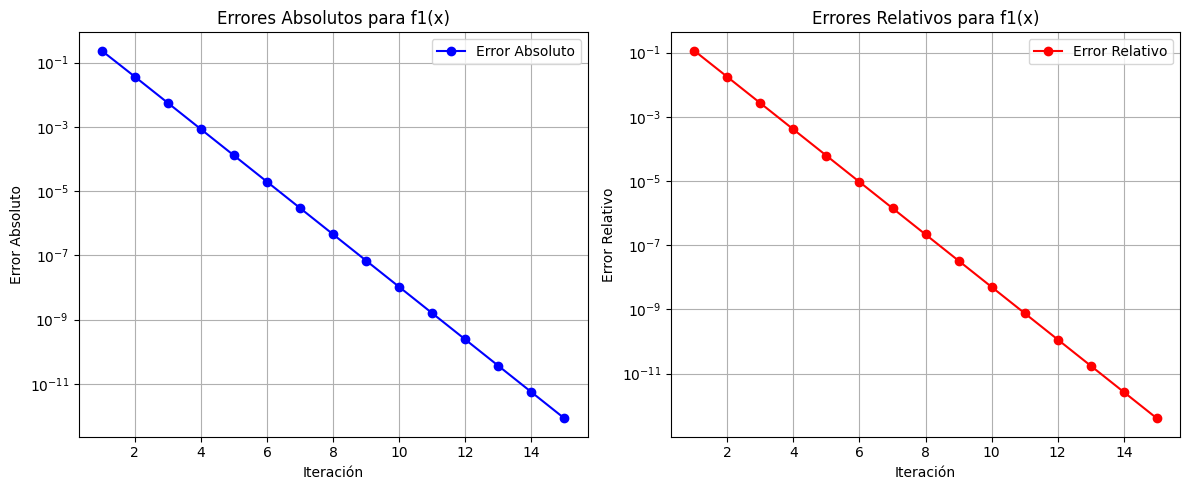

Procesando f2(x) con g(x) = (x + 2)**0.333333333333333
-Raíz aprox: 1.52137970680453


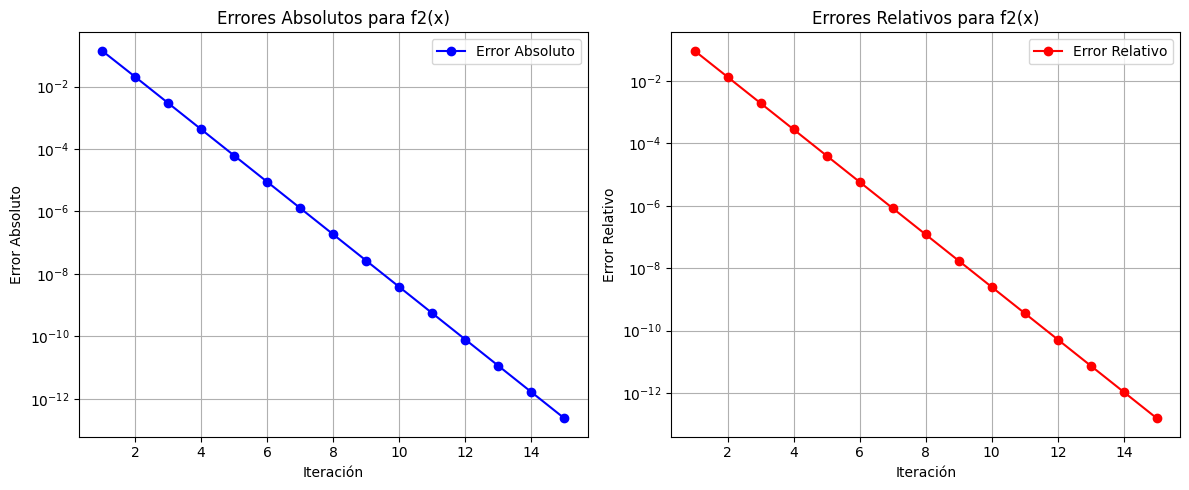

Procesando f3(x) con g(x) = 1.49534878122122*(x**2)**0.25
-Raíz aprox: 2.23606797749903


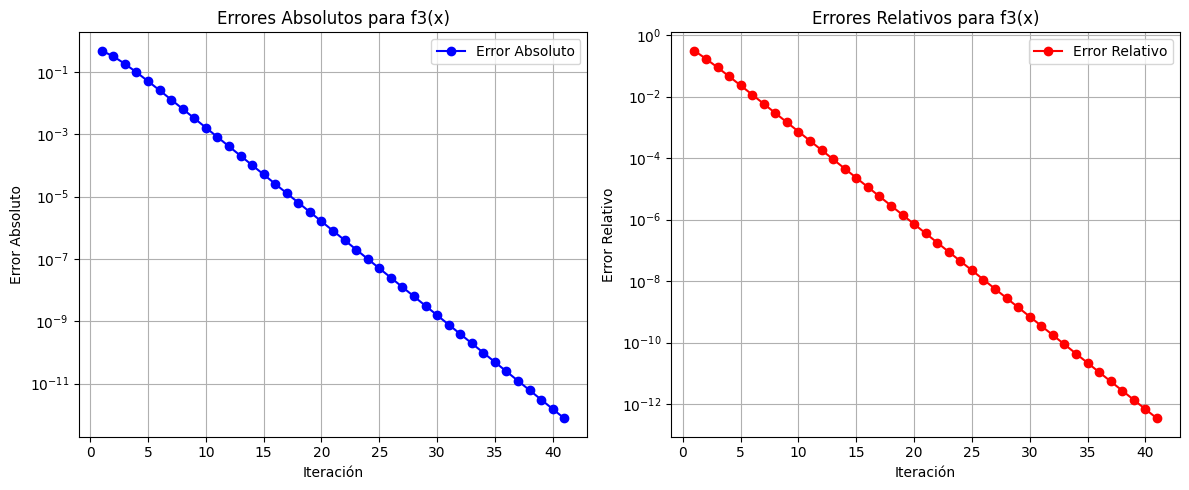

Procesando f4(x) con g(x) = (x + 1)**0.2
-Raíz aprox: 1.16730397826140


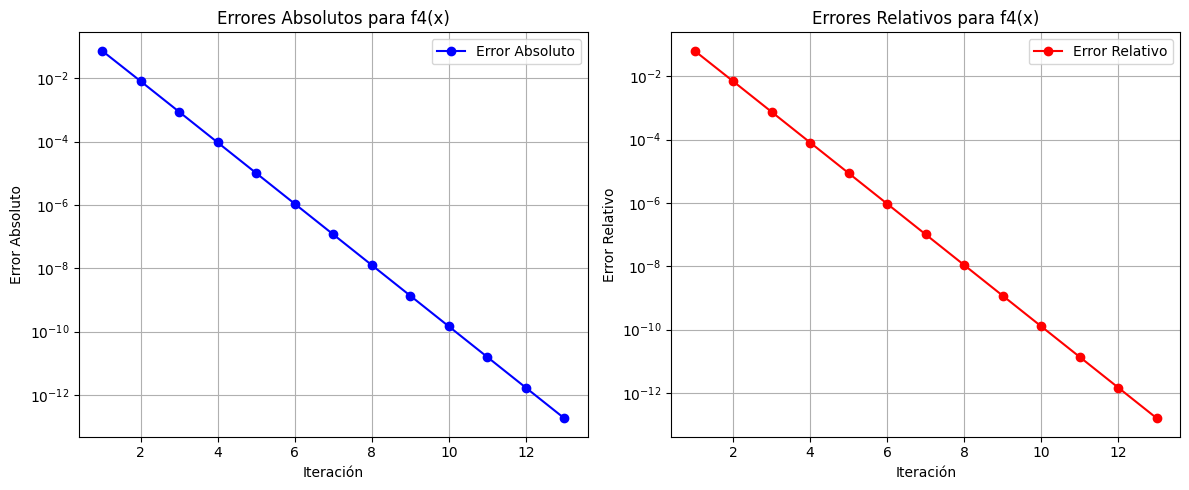

Procesando f5(x) con g(x) = exp(x)/4
-Raíz aprox: 0.357402956181775


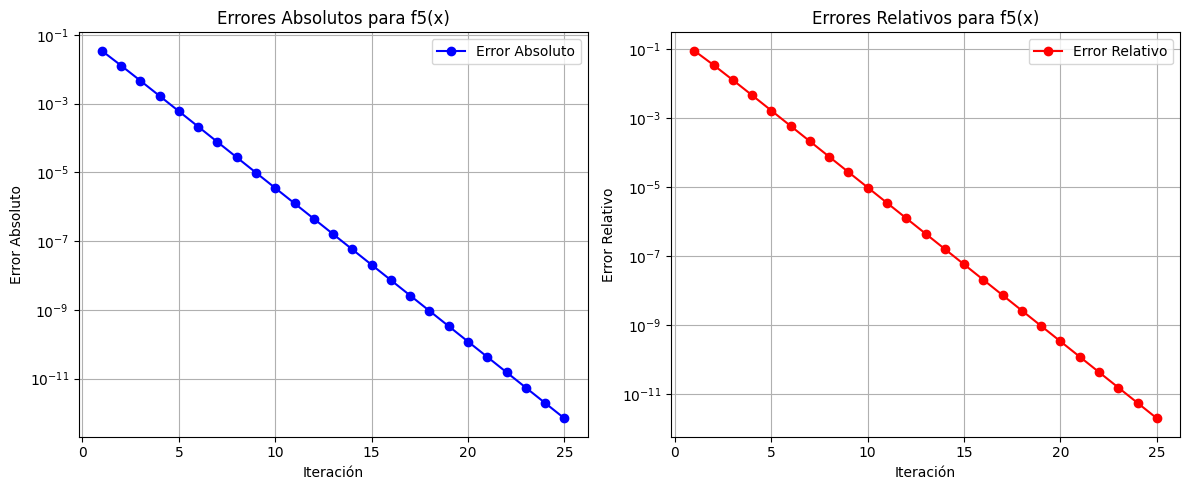

In [103]:
Funciones_g = {
    "f1(x)": (2*x + 5)**(1/3),
    "f2(x)": (x + 2)**(1/3),
    "f3(x)": (5*x**2)**(1/4), #ya
    "f4(x)": (x + 1)**(1/5),
    "f5(x)": sp.exp(x) / 4  # ya solucione ya, lo que pasaba es que con otra forma que yo habia sacado la g(x) no me daban las raices, ahora que transforme de otra fomra, si me da
}

maximas_iteraciones = 50
toleration = 1e-12

def punto_fijo(g, x0):
    iteraciones = []
    errores_absolutos = []
    errores_relativos = []

    for i in range(maximas_iteraciones):
        x1 = g.evalf(subs={x: x0})
        iteraciones.append((i + 1, x0, x1))

        #CALCILO MIS ERRORES
        if i > 0:
            error_absoluto = abs(x1 - x0)
            errores_absolutos.append(error_absoluto)

            error_relativo = abs((x1 - x0) / x1) if x1 != 0 else float('inf')
            errores_relativos.append(error_relativo)

        if abs(x1 - x0) < toleration:
            return x1, iteraciones, errores_absolutos, errores_relativos  #que me devuelva la raiz arpox y las iteraciones
        x0 = x1  # actualizo el valor de x

    return None, iteraciones, errores_absolutos, errores_relativos #si no se encuentra la raiz en el nro max de iteraciones

#entonces ahora lo que voy a hacer es que voy a hacer este metodo pero para todas mis funciones dentro d mi dicccionario
for nombre, g in Funciones_g.items():
    print(f"Procesando {nombre} con g(x) = {g}")

    X0 = 0.5
    raiz, iteraciones, errores_absolutos, errores_relativos = punto_fijo(g, X0)

    if raiz is not None:
      print(f"-Raíz aprox: {raiz}")
    else:
      print(f"-No se encontro una raíz en el número máximo de iteraciones")

    #Grafico los errores
    plt.figure(figsize=(12, 5))

    #error abs
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(errores_absolutos) + 1), errores_absolutos, marker='o', color='b', label='Error Absoluto')
    plt.yscale('log')
    plt.title(f'Errores Absolutos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Absoluto')
    plt.grid(True)
    plt.legend()

    #error relat
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(errores_relativos) + 1), errores_relativos, marker='o', color='r', label='Error Relativo')
    plt.yscale('log')
    plt.title(f'Errores Relativos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Relativo')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

##Punto d

###Tolerancia 1e-2

Procesando f1(x) = x^3-2*x-5
- Raíz aprox: 2.09455771585006


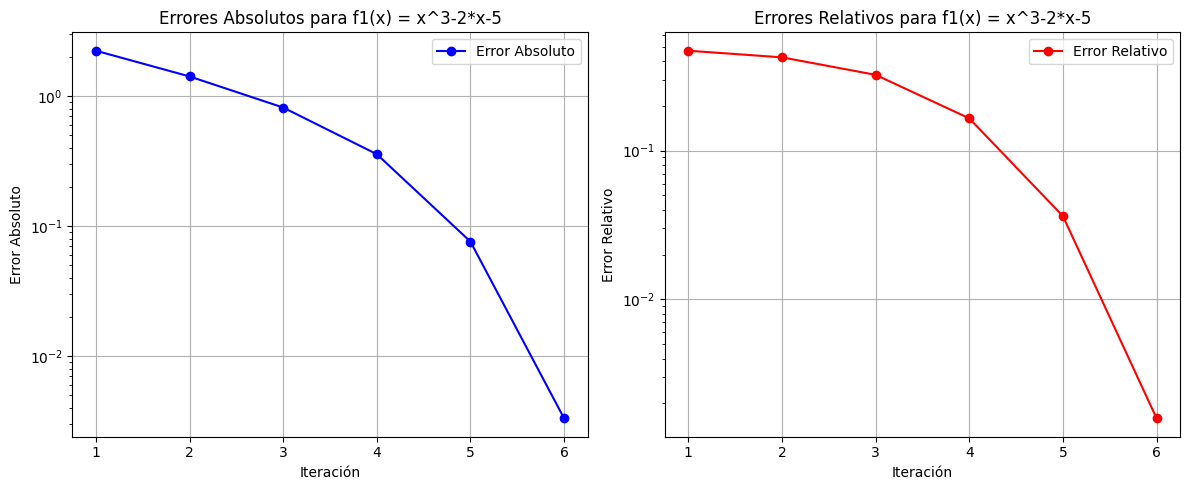

Procesando f2(x) = x^3-x-2
- Raíz aprox: 1.52144146513514


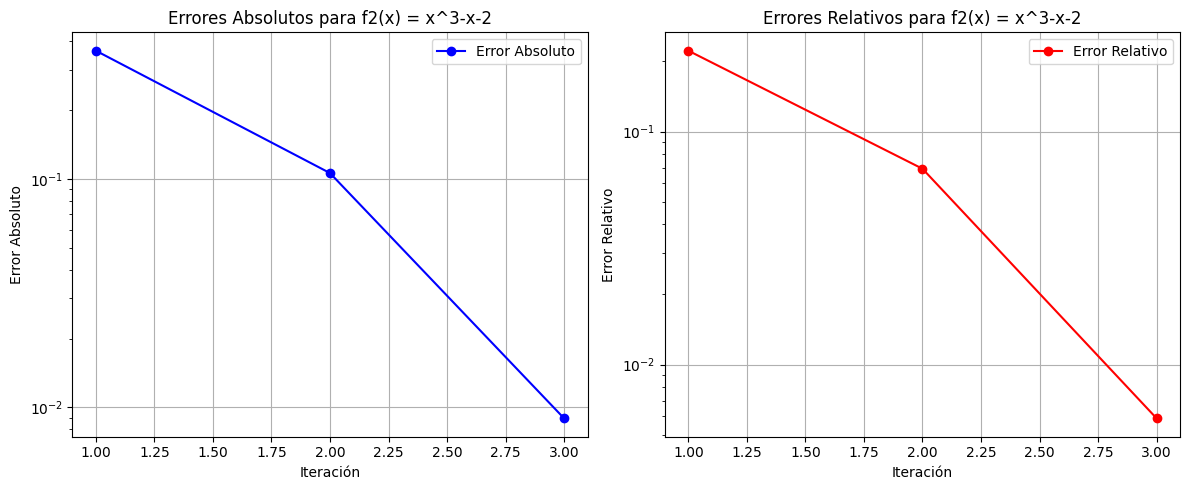

Procesando f3(x) = x^4-5*x^2
- Raíz aprox: 0.00505113843843630


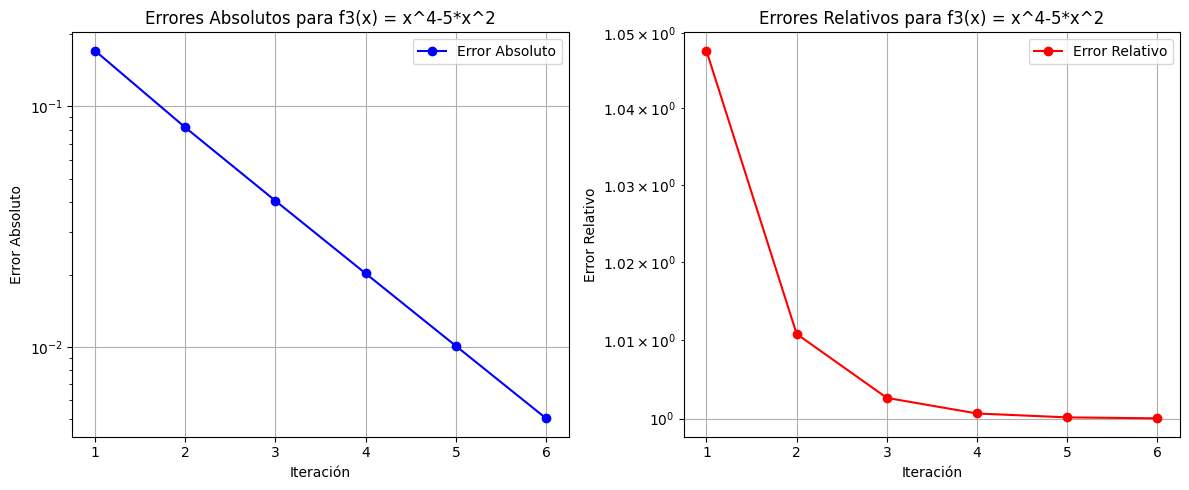

Procesando f4(x) = x^5-x-1
- Raíz aprox: 1.16730408282301


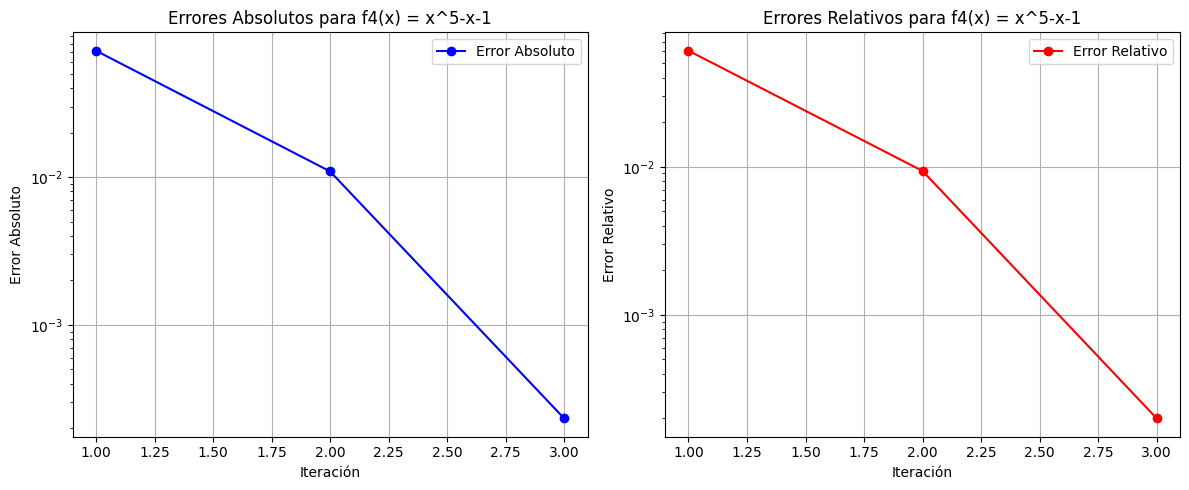

Procesando f5(x) = e^x-4*x
- Raíz aprox: 0.357402949373307


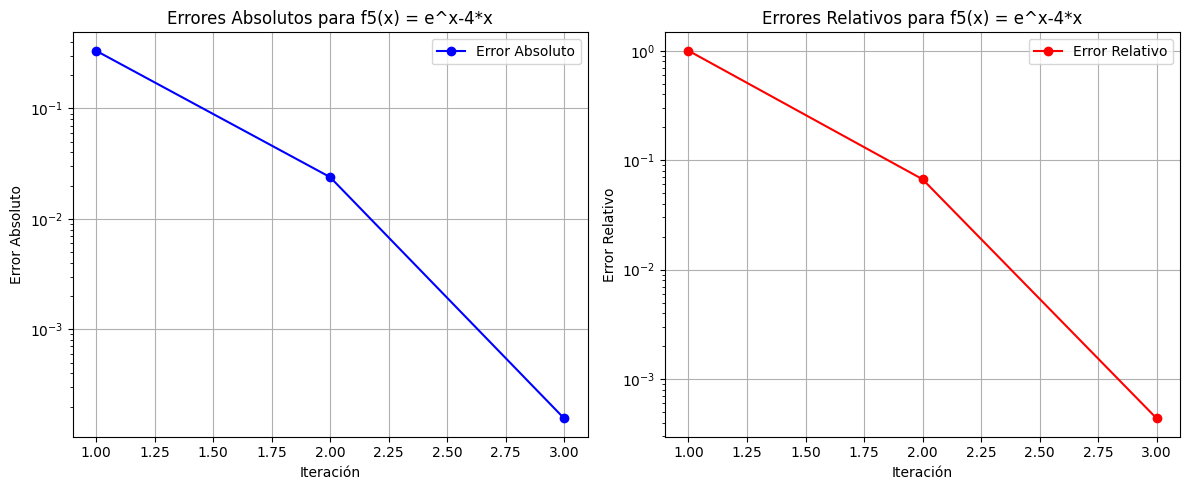

In [104]:
max_iter = 100
tol = 1e-2

#Ahora defino el metodo de newton
def newton(f, x0):
    f_derivada = sp.diff(f, x)
    iteraciones = []
    errores_absolutos = []
    errores_relativos = []

    for i in range(max_iter):
        f_x0 = f.evalf(subs={x: x0})
        f_prime_x0 = f_derivada.evalf(subs={x: x0})

        if f_prime_x0 == 0:
            print(f" - Derivada cero en la iteración {i + 1}. No se puede continuar.")
            return None, iteraciones, errores_absolutos, errores_relativos

        # calculo la nueva aprox
        x1 = x0 - f_x0 / f_prime_x0
        iteraciones.append((i + 1, x0, x1))

        #calculo mis errores
        if i > 0:
            error_absoluto = abs(x1 - x0)
            errores_absolutos.append(error_absoluto)

            error_relativo = abs((x1 - x0) / x1) if x1 != 0 else float('inf')
            errores_relativos.append(error_relativo)

        if abs(x1 - x0) < tol:
            return x1, iteraciones, errores_absolutos, errores_relativos

        x0 = x1

    return None, iteraciones, errores_absolutos, errores_relativos

#Ahora aplico el metodo de newton para todas las funciones de mi lista
for nombre, f in Funciones.items():
    print(f"Procesando {nombre}")

    x0 = 1
    raiz, iteraciones, errores_absolutos, errores_relativos = newton(f, x0)

    if raiz is not None:
        print(f"- Raíz aprox: {raiz}")
    else:
        print("- No se encontró una raíz en el número máximo de iteraciones")

    #Grafico mis erroes
    plt.figure(figsize=(12, 5))

    #erroes abs
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(errores_absolutos) + 1), errores_absolutos, marker='o', color='b', label='Error Absoluto')
    plt.yscale('log')
    plt.title(f'Errores Absolutos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Absoluto')
    plt.grid(True)
    plt.legend()

    #error relat
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(errores_relativos) + 1), errores_relativos, marker='o', color='r', label='Error Relativo')
    plt.yscale('log')
    plt.title(f'Errores Relativos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Relativo')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

###Tolerancia 1e-5

Procesando f1(x) = x^3-2*x-5
- Raíz aprox: 2.09455148156421


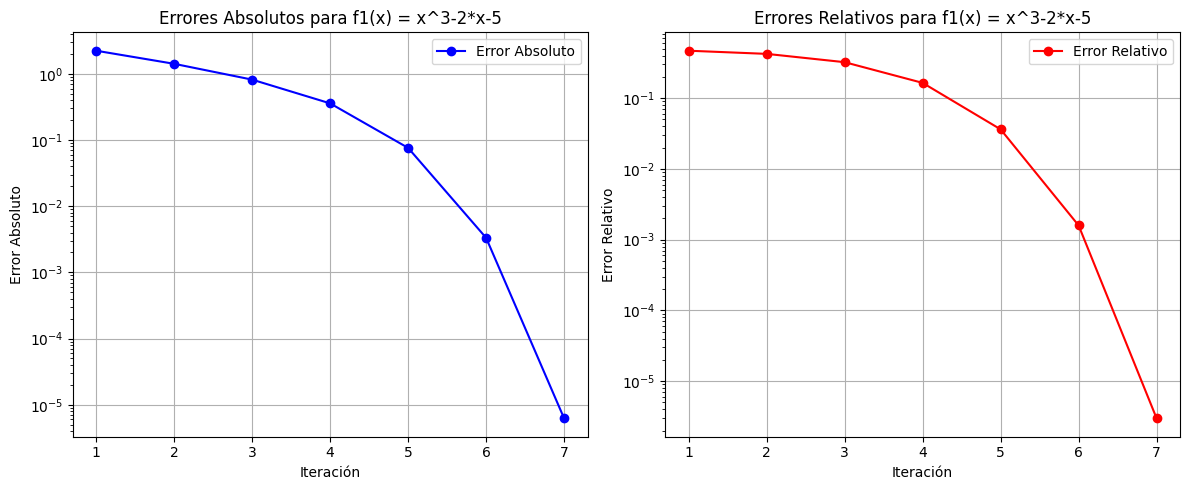

Procesando f2(x) = x^3-x-2
- Raíz aprox: 1.52137970680457


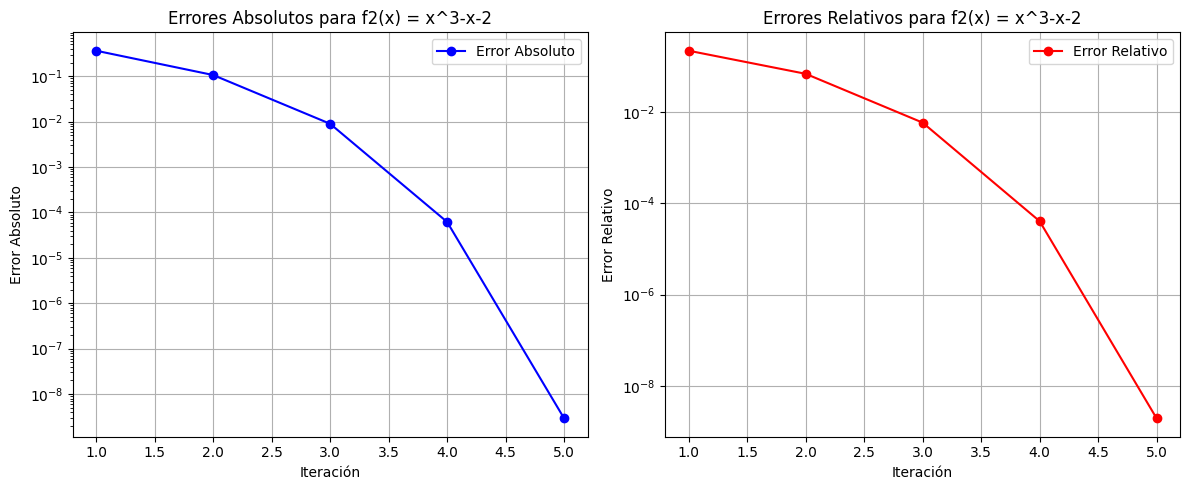

Procesando f3(x) = x^4-5*x^2
- Raíz aprox: 0.00000986543764029058


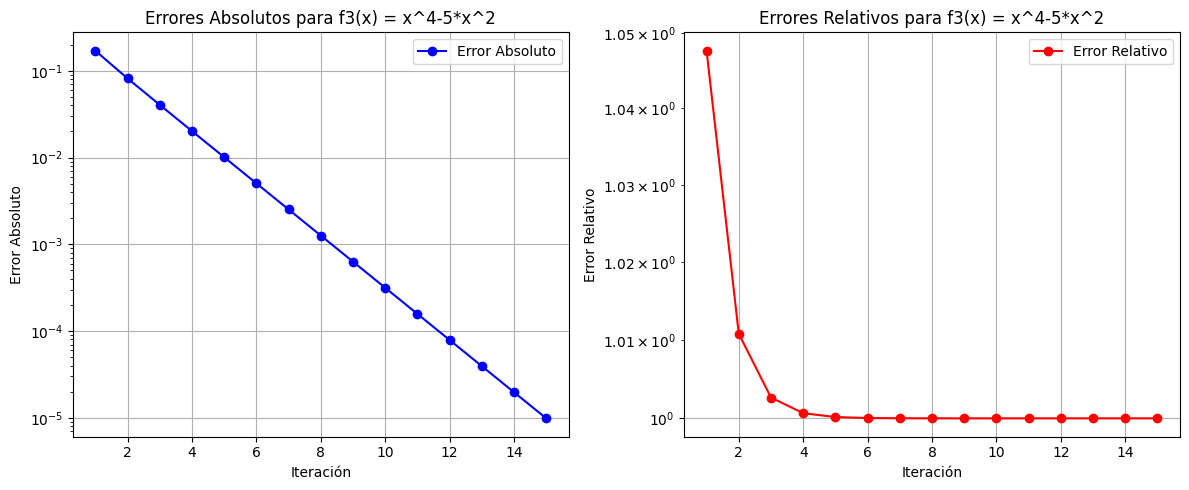

Procesando f4(x) = x^5-x-1
- Raíz aprox: 1.16730397826144


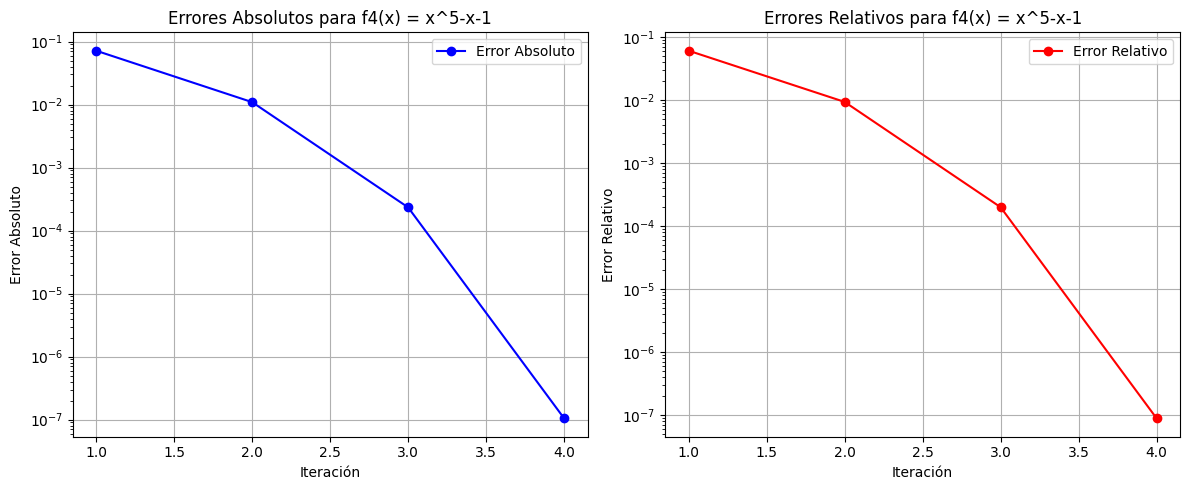

Procesando f5(x) = e^x-4*x
- Raíz aprox: 0.357402956181389


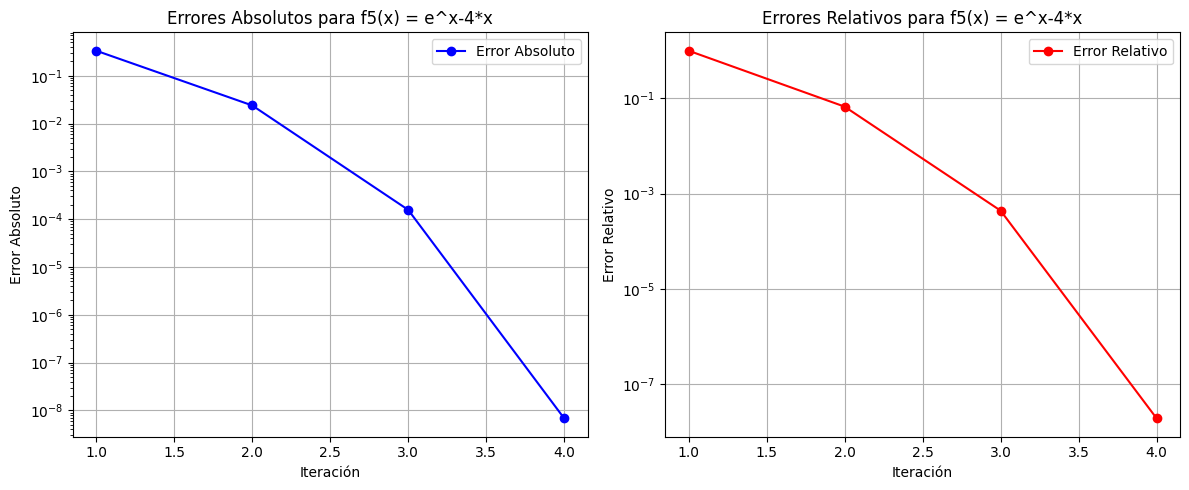

In [105]:
max_iter = 100
tol = 1e-5

#Ahora defino el metodo de newton
def newton(f, x0):
    f_derivada = sp.diff(f, x)
    iteraciones = []
    errores_absolutos = []
    errores_relativos = []

    for i in range(max_iter):
        f_x0 = f.evalf(subs={x: x0})
        f_prime_x0 = f_derivada.evalf(subs={x: x0})

        if f_prime_x0 == 0:
            print(f" - Derivada cero en la iteración {i + 1}. No se puede continuar.")
            return None, iteraciones, errores_absolutos, errores_relativos

        # calculo la nueva aprox
        x1 = x0 - f_x0 / f_prime_x0
        iteraciones.append((i + 1, x0, x1))

        #calculo mis errores
        if i > 0:
            error_absoluto = abs(x1 - x0)
            errores_absolutos.append(error_absoluto)

            error_relativo = abs((x1 - x0) / x1) if x1 != 0 else float('inf')
            errores_relativos.append(error_relativo)

        if abs(x1 - x0) < tol:
            return x1, iteraciones, errores_absolutos, errores_relativos

        x0 = x1

    return None, iteraciones, errores_absolutos, errores_relativos

#Ahora aplico el metodo de newton para todas las funciones de mi lista
for nombre, f in Funciones.items():
    print(f"Procesando {nombre}")

    x0 = 1
    raiz, iteraciones, errores_absolutos, errores_relativos = newton(f, x0)

    if raiz is not None:
        print(f"- Raíz aprox: {raiz}")
    else:
        print("- No se encontró una raíz en el número máximo de iteraciones")

    #Grafico mis erroes
    plt.figure(figsize=(12, 5))

    #erroes abs
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(errores_absolutos) + 1), errores_absolutos, marker='o', color='b', label='Error Absoluto')
    plt.yscale('log')
    plt.title(f'Errores Absolutos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Absoluto')
    plt.grid(True)
    plt.legend()

    #error relat
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(errores_relativos) + 1), errores_relativos, marker='o', color='r', label='Error Relativo')
    plt.yscale('log')
    plt.title(f'Errores Relativos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Relativo')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

###Tolerancia 1e-7

Procesando f1(x) = x^3-2*x-5
- Raíz aprox: 2.09455148154233


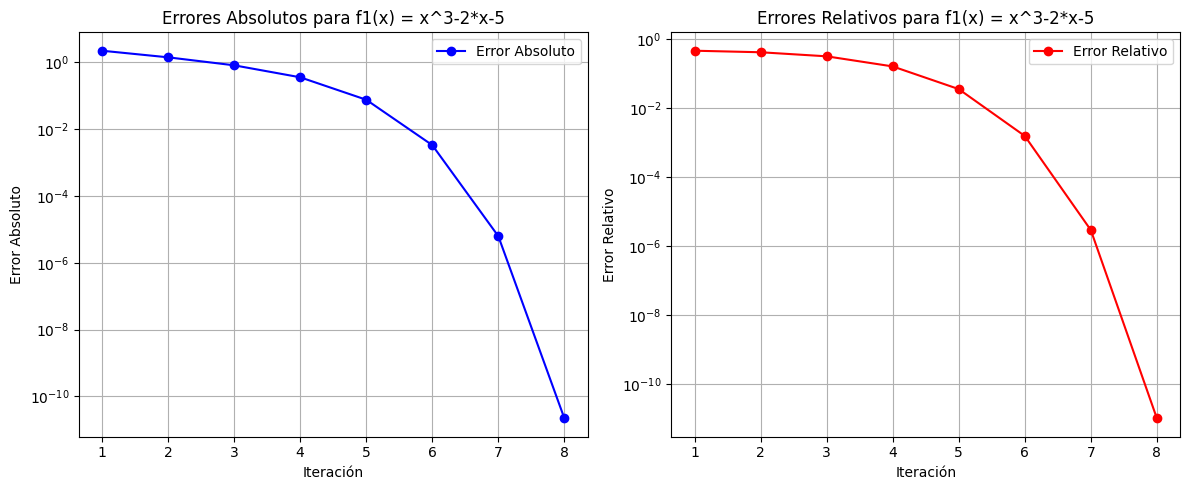

Procesando f2(x) = x^3-x-2
- Raíz aprox: 1.52137970680457


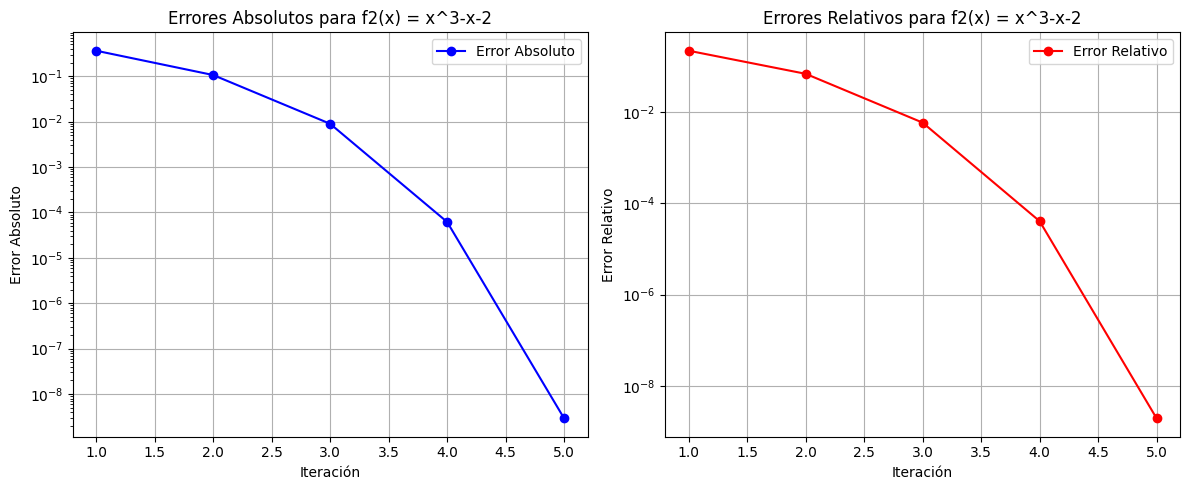

Procesando f3(x) = x^4-5*x^2
- Raíz aprox: 7.70737315627699E-8


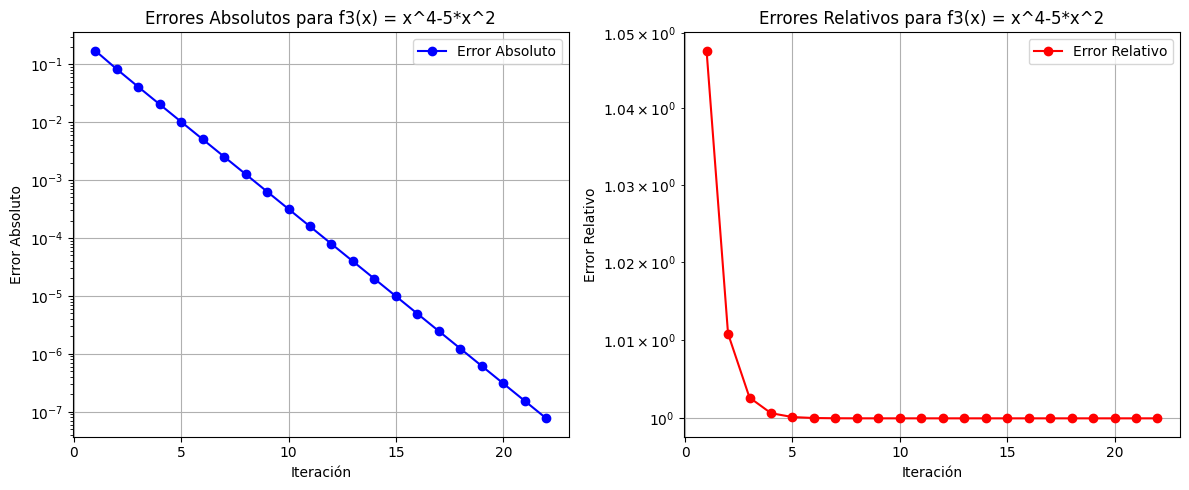

Procesando f4(x) = x^5-x-1
- Raíz aprox: 1.16730397826142


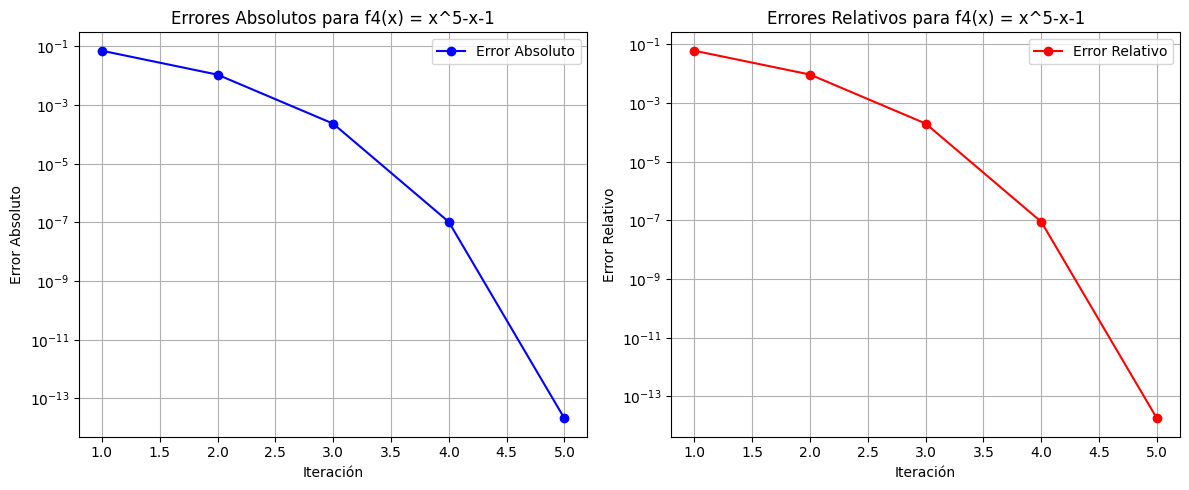

Procesando f5(x) = e^x-4*x
- Raíz aprox: 0.357402956181389


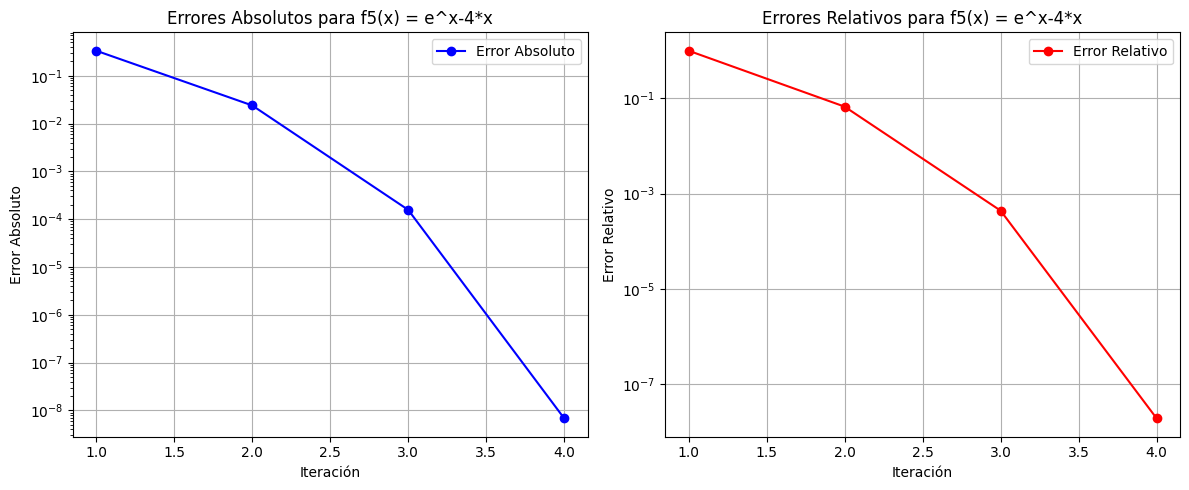

In [107]:
max_iter = 100
tol = 1e-7

#Ahora defino el metodo de newton
def newton(f, x0):
    f_derivada = sp.diff(f, x)
    iteraciones = []
    errores_absolutos = []
    errores_relativos = []

    for i in range(max_iter):
        f_x0 = f.evalf(subs={x: x0})
        f_prime_x0 = f_derivada.evalf(subs={x: x0})

        if f_prime_x0 == 0:
            print(f" - Derivada cero en la iteración {i + 1}. No se puede continuar.")
            return None, iteraciones, errores_absolutos, errores_relativos

        # calculo la nueva aprox
        x1 = x0 - f_x0 / f_prime_x0
        iteraciones.append((i + 1, x0, x1))

        #calculo mis errores
        if i > 0:
            error_absoluto = abs(x1 - x0)
            errores_absolutos.append(error_absoluto)

            error_relativo = abs((x1 - x0) / x1) if x1 != 0 else float('inf')
            errores_relativos.append(error_relativo)

        if abs(x1 - x0) < tol:
            return x1, iteraciones, errores_absolutos, errores_relativos

        x0 = x1

    return None, iteraciones, errores_absolutos, errores_relativos

#Ahora aplico el metodo de newton para todas las funciones de mi lista
for nombre, f in Funciones.items():
    print(f"Procesando {nombre}")

    x0 = 1
    raiz, iteraciones, errores_absolutos, errores_relativos = newton(f, x0)

    if raiz is not None:
        print(f"- Raíz aprox: {raiz}")
    else:
        print("- No se encontró una raíz en el número máximo de iteraciones")

    #Grafico mis erroes
    plt.figure(figsize=(12, 5))

    #erroes abs
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(errores_absolutos) + 1), errores_absolutos, marker='o', color='b', label='Error Absoluto')
    plt.yscale('log')
    plt.title(f'Errores Absolutos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Absoluto')
    plt.grid(True)
    plt.legend()

    #error relat
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(errores_relativos) + 1), errores_relativos, marker='o', color='r', label='Error Relativo')
    plt.yscale('log')
    plt.title(f'Errores Relativos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Relativo')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

###Tolerancia 1e-12

Procesando f1(x) = x^3-2*x-5
- Raíz aprox: 2.09455148154233


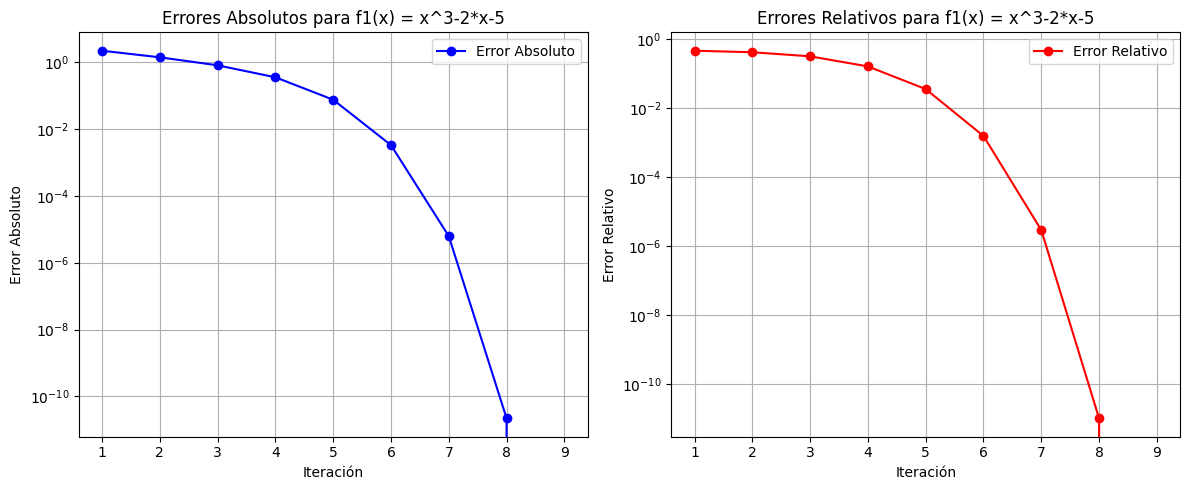

Procesando f2(x) = x^3-x-2
- Raíz aprox: 1.52137970680457


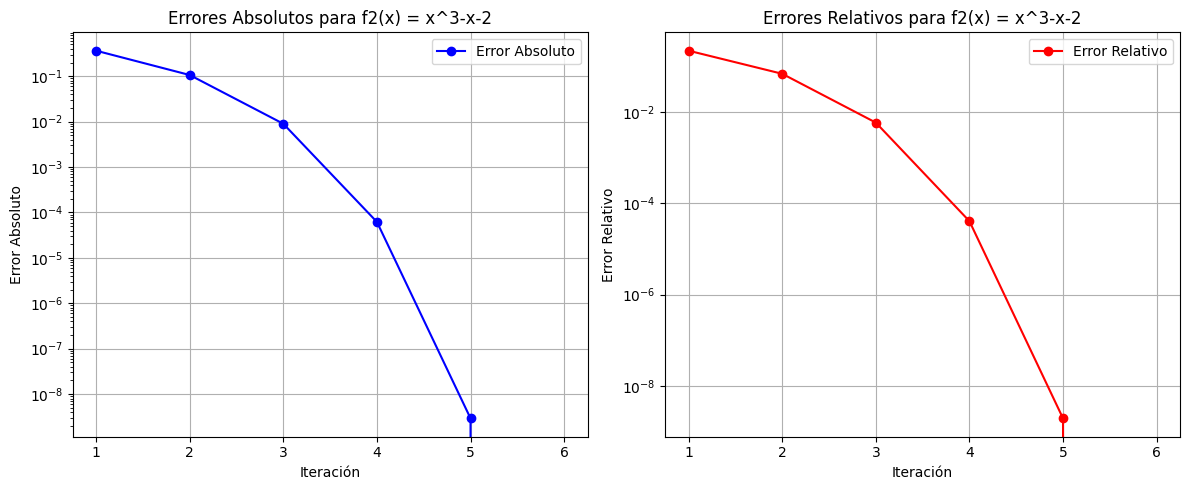

Procesando f3(x) = x^4-5*x^2
- Raíz aprox: 5.88025906088026E-13


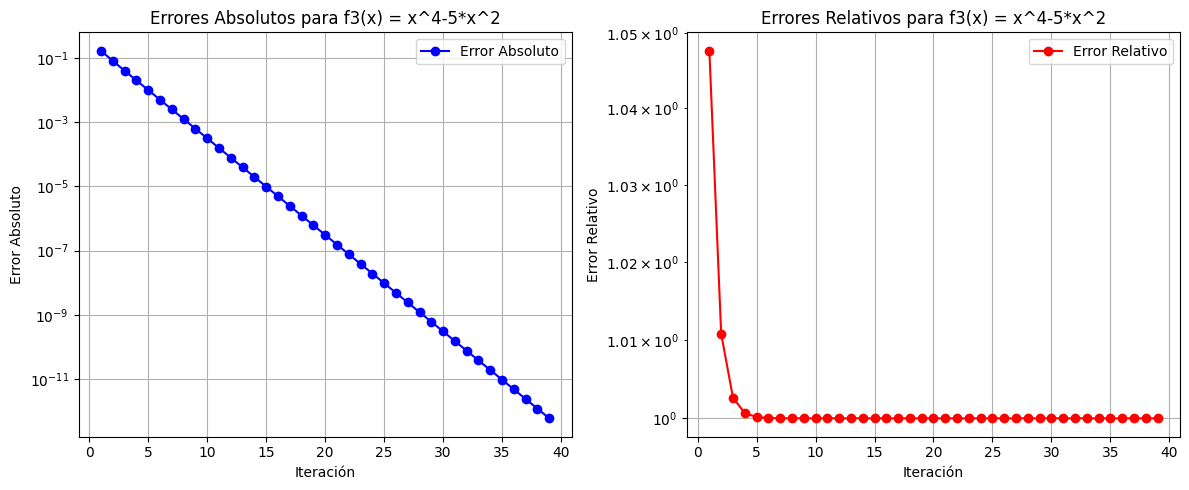

Procesando f4(x) = x^5-x-1
- Raíz aprox: 1.16730397826142


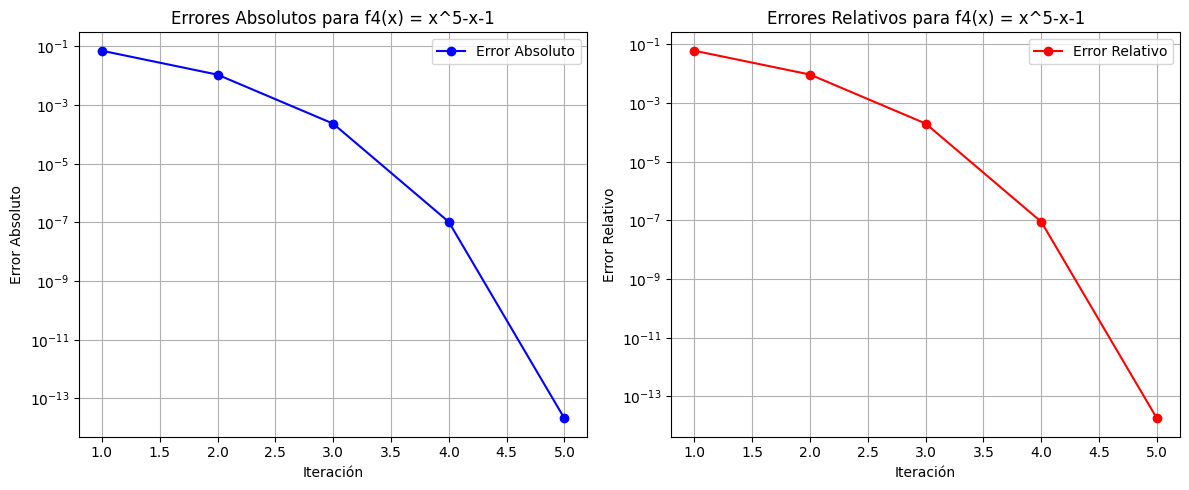

Procesando f5(x) = e^x-4*x
- Raíz aprox: 0.357402956181389


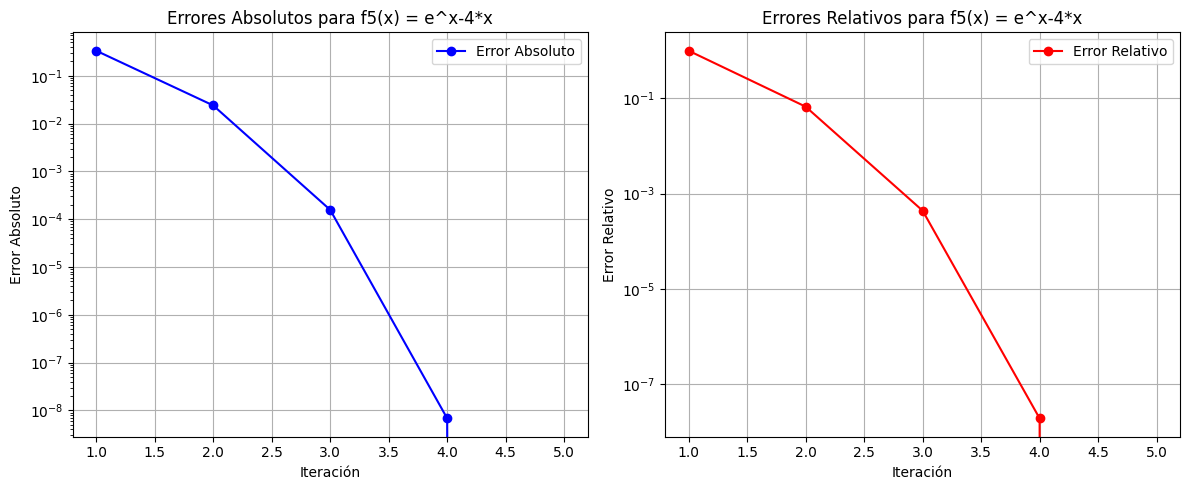

In [108]:
max_iter = 100
tol = 1e-12

#Ahora defino el metodo de newton
def newton(f, x0):
    f_derivada = sp.diff(f, x)
    iteraciones = []
    errores_absolutos = []
    errores_relativos = []

    for i in range(max_iter):
        f_x0 = f.evalf(subs={x: x0})
        f_prime_x0 = f_derivada.evalf(subs={x: x0})

        if f_prime_x0 == 0:
            print(f" - Derivada cero en la iteración {i + 1}. No se puede continuar.")
            return None, iteraciones, errores_absolutos, errores_relativos

        # calculo la nueva aprox
        x1 = x0 - f_x0 / f_prime_x0
        iteraciones.append((i + 1, x0, x1))

        #calculo mis errores
        if i > 0:
            error_absoluto = abs(x1 - x0)
            errores_absolutos.append(error_absoluto)

            error_relativo = abs((x1 - x0) / x1) if x1 != 0 else float('inf')
            errores_relativos.append(error_relativo)

        if abs(x1 - x0) < tol:
            return x1, iteraciones, errores_absolutos, errores_relativos

        x0 = x1

    return None, iteraciones, errores_absolutos, errores_relativos

#Ahora aplico el metodo de newton para todas las funciones de mi lista
for nombre, f in Funciones.items():
    print(f"Procesando {nombre}")

    x0 = 1
    raiz, iteraciones, errores_absolutos, errores_relativos = newton(f, x0)

    if raiz is not None:
        print(f"- Raíz aprox: {raiz}")
    else:
        print("- No se encontró una raíz en el número máximo de iteraciones")

    #Grafico mis erroes
    plt.figure(figsize=(12, 5))

    #erroes abs
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(errores_absolutos) + 1), errores_absolutos, marker='o', color='b', label='Error Absoluto')
    plt.yscale('log')
    plt.title(f'Errores Absolutos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Absoluto')
    plt.grid(True)
    plt.legend()

    #error relat
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(errores_relativos) + 1), errores_relativos, marker='o', color='r', label='Error Relativo')
    plt.yscale('log')
    plt.title(f'Errores Relativos para {nombre}')
    plt.xlabel('Iteración')
    plt.ylabel('Error Relativo')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

#Comparación de la cantidad de iteracciones por método

La cantidad de iteracion por ejemplo en el método de bisección es superior a las otras dos, también al mismo tiempo entre las otras dos podemos ver que Newton utiliza menos iteraciones que Punto fijo.

Viendo los resultados obtenidos por mi código se puede decir facilmente si, que el método de bisección es el que mas iteraciones utiliza para llegar a las raíces, luego en los otros dos se ve que van más a la par, hay por ejemplo una función que en el método de punto fijo que tiene un par de iteraciones menos que por método de Newton. Igualmente en general se puede decir que el que ocupa menos iteraciones para llegar a las raíces es el método de Newton.